In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip -q install pandas numpy matplotlib scikit-learn langdetect emoji regex datasets transformers accelerate

In [3]:
import os
import re
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [8]:
# ====== CHỈNH CHỖ NÀY ======
DATA_PATH = "C:\\Users\\ADMIN\\Desktop\\2025\\Web-Data-Analysis\\TSN_Data\\raw_data\\raw_data.csv"
OUTPUT_DIR = "C:\\Users\\ADMIN\\Desktop\\tsn_review_analytics\\TSN_Data\\processed_data"
RANDOM_SEED = 42


# Model cho tokenize (chọn 1)
BASELINE_MODEL_NAME = "bert-base-multilingual-cased"  # mBERT baseline
MODEL_NAME = "xlm-roberta-base"            # XLM-R đề xuất

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(RANDOM_SEED)


In [9]:
def load_data(path: str) -> pd.DataFrame:
    path = str(path)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không thấy file: {path}")

    ext = Path(path).suffix.lower()
    if ext == ".csv":
        df = pd.read_csv(path)
    elif ext == ".json":
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        # obj có thể là list[dict] hoặc dict chứa "items"
        if isinstance(obj, dict) and "items" in obj and isinstance(obj["items"], list):
            obj = obj["items"]
        df = pd.json_normalize(obj)
    elif ext in [".jsonl", ".ndjson"]:
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
        df = pd.json_normalize(rows)
    else:
        raise ValueError(f"Định dạng chưa hỗ trợ: {ext}. Hãy xuất CSV/JSON/JSONL.")
    return df

df_raw = load_data(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head(3)


Raw shape: (8333, 6)


,title,url,stars,name,reviewUrl,text
0,Tan Son Nhat International Airport,https://www.google.com/maps/search/?api=1&quer...,4,Thieu Long Chau,https://www.google.com/maps/reviews/data=!4m8!...,NaN
1,Tan Son Nhat International Airport,https://www.google.com/maps/search/?api=1&quer...,4,My Anh,https://www.google.com/maps/reviews/data=!4m8!...,NaN
2,Tan Son Nhat International Airport,https://www.google.com/maps/search/?api=1&quer...,5,Thanh Nhon Nguyen,https://www.google.com/maps/reviews/data=!4m8!...,Cảng hàng không quốc tế Tân Sơn Nhất phục vụ q...


In [10]:
import pandas as pd
import numpy as np
import re

# df_raw là dataframe bạn load lên từ file
df = df_raw[["title","url","stars","name","reviewUrl","text"]].copy()

df = df.rename(columns={
    "stars": "rating",
    "name": "author",
    "reviewUrl": "review_id"
})

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# ✅ dùng pandas string dtype để giữ NA đúng nghĩa
df["text_raw"] = df["text"].astype("string")

# chuẩn hoá NA -> ""
df["text_raw"] = df["text_raw"].fillna("").str.strip()

# nếu trong data có literal "nan/none/null" (do export), coi như rỗng
bad_literals = ["nan", "none", "null", "na"]
mask_bad = df["text_raw"].str.lower().isin(bad_literals)
df.loc[mask_bad, "text_raw"] = ""

# thống kê số dòng rating-only (text rỗng)
rating_only_count = (df["text_raw"] == "").sum()
print("Số dòng chỉ có rating (text rỗng):", rating_only_count)

# lọc rating hợp lệ trước
df = df[df["rating"].between(1, 5)].copy()


Số dòng chỉ có rating (text rỗng): 3593


In [11]:
def audit_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = []
    rep.append(("n_rows", len(df)))
    rep.append(("n_cols", df.shape[1]))

    # missing %
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    for col, pct in miss.items():
        rep.append((f"missing_%_{col}", round(float(pct), 3)))

    # empty text %
    empty_text_pct = df["text"].astype(str).str.strip().eq("").mean() * 100
    rep.append(("empty_text_%", round(float(empty_text_pct), 3)))

    # rating out of range
    oor_pct = (~df["rating"].between(1, 5)).mean() * 100
    rep.append(("rating_out_of_range_%", round(float(oor_pct), 3)))

    # duplicate review_id
    dup_pct = df["review_id"].astype(str).duplicated().mean() * 100
    rep.append(("duplicate_review_id_%", round(float(dup_pct), 3)))

    return pd.DataFrame(rep, columns=["metric", "value"])

audit_before = audit_report(df)
audit_before


,metric,value
0,n_rows,8333.000
1,n_cols,7.000
2,missing_%_text,43.118
3,missing_%_title,0.000
4,missing_%_url,0.000
5,missing_%_rating,0.000
6,missing_%_author,0.000
7,missing_%_review_id,0.000
8,missing_%_text_raw,0.000
9,empty_text_%,0.000


In [12]:
import re

BASIC_PUNCT = r"\.\,\!\?\:\;\-\(\)\/"
RE_KEEP = re.compile(rf"[^\w\s{BASIC_PUNCT}]", flags=re.UNICODE)

RE_URL = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
RE_EMAIL = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", flags=re.IGNORECASE)
RE_WS = re.compile(r"\s+")

def clean_text(s: str,
               remove_url=True,
               remove_email=True,
               remove_special=True) -> str:
    s = str(s).replace("\u200b", "").strip()
    if remove_url:
        s = RE_URL.sub(" ", s)
    if remove_email:
        s = RE_EMAIL.sub(" ", s)
    if remove_special:
        # ✅ loại emoji / ký tự lạ, vẫn giữ unicode letters (tiếng Việt OK)
        s = RE_KEEP.sub(" ", s)
    s = RE_WS.sub(" ", s).strip()
    return s

# Áp dụng clean_text
df["text_clean"] = df["text_raw"].apply(clean_text)

# ✅ Loại bỏ các trường hợp chỉ rating hoặc text quá ngắn (<5 ký tự)
df = df[(df["text_clean"].ne("")) & (df["text_clean"].str.len() >= 5)].copy()

print("Còn lại sau khi bỏ rating-only và <5 ký tự:", df.shape)

Còn lại sau khi bỏ rating-only và <5 ký tự: (4541, 8)


In [13]:
def star_to_label(r: float) -> str:
    r = int(r)
    if r in [1, 2, 3]:
        return "negative"
    return "positive"

label2id = {"negative": 0, "neutral": 1, "positive": 2}

df["label"] = df["rating"].apply(star_to_label)
df["label_id"] = df["label"].map(label2id)

df[["rating","label"]].value_counts().sort_index()


rating  label   
1       negative    2027
2       negative     459
3       negative     556
4       positive     587
5       positive     912
Name: count, dtype: int64

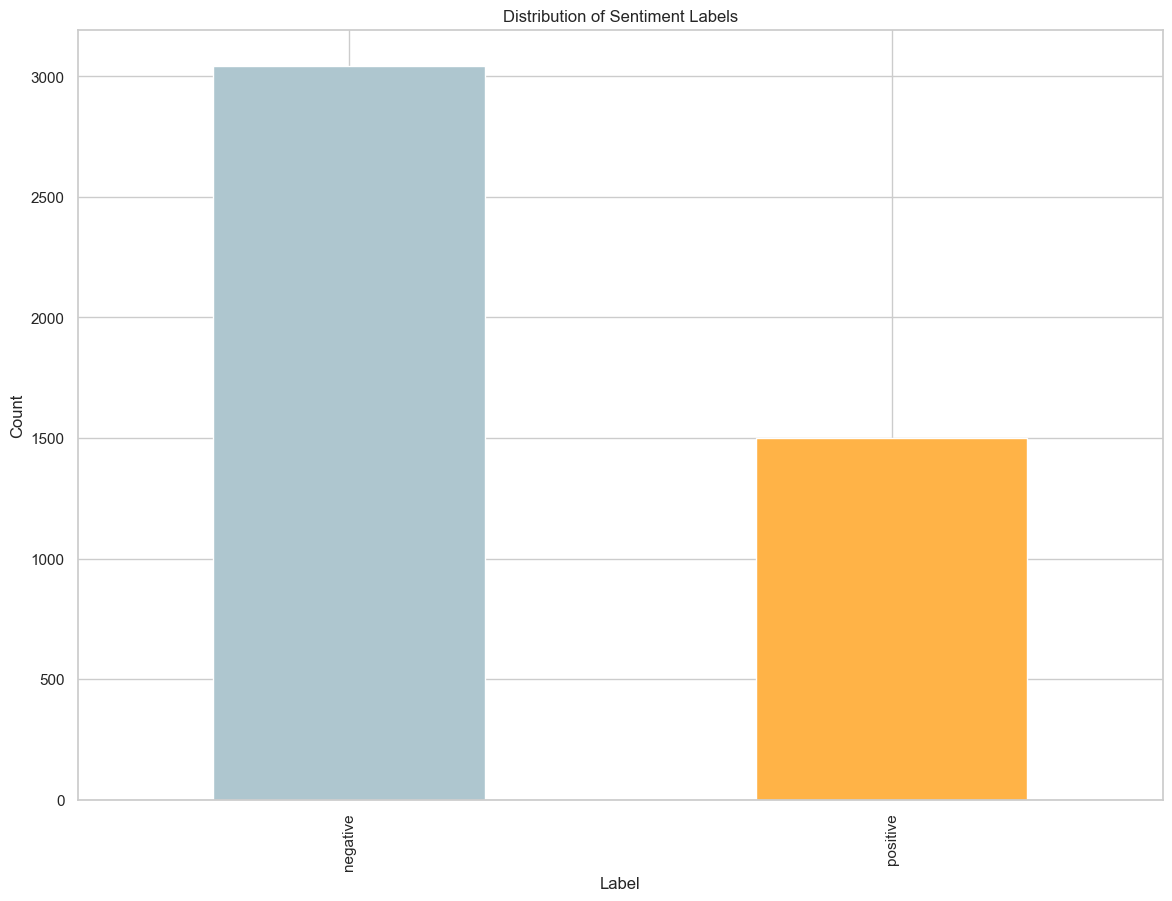

In [46]:
import matplotlib.pyplot as plt

# Vẽ bar chart với 2 màu pastel khác nhau
df['label'].value_counts().plot(
    kind='bar',
    color=['#AEC6CF', '#FFB347']  # pastel xanh và pastel cam
)

plt.title('Distribution of Sentiment Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [15]:
df['label'].value_counts()

label
negative    3042
positive    1499
Name: count, dtype: int64

In [12]:
import pandas as pd
import numpy as np

# 1) Drop 2 cột theo yêu cầu (nếu có)
cols_to_drop = [c for c in ["text", "text_raw"] if c in df.columns]
df = df.drop(columns=cols_to_drop).copy()

# 2) đảm bảo text_clean không bị NA lạ
df["text_clean"] = df["text_clean"].astype("string").fillna("").str.strip()

# 3) nếu có literal 'nan/none/null' (do export) thì coi như rỗng
bad_literals = {"nan", "none", "null", "na"}
mask_bad = df["text_clean"].str.lower().isin(bad_literals)
df.loc[mask_bad, "text_clean"] = ""

print("Columns now:", df.columns.tolist())
print("Rows:", len(df))
print("Empty text_clean:", (df["text_clean"] == "").sum())

df.head(3)


Columns now: ['title', 'url', 'rating', 'author', 'review_id', 'text_clean', 'label', 'label_id']
Rows: 4727
Empty text_clean: 0


,title,url,rating,author,review_id,text_clean,label,label_id
2,Tan Son Nhat International Airport,https://www.google.com/maps/search/?api=1&quer...,5,Thanh Nhon Nguyen,https://www.google.com/maps/reviews/data=!4m8!...,Cảng hàng không quốc tế Tân Sơn Nhất phục vụ q...,positive,2
3,Tan Son Nhat International Airport,https://www.google.com/maps/search/?api=1&quer...,1,HY Kim,https://www.google.com/maps/reviews/data=!4m8!...,여행의 마지막 기억을 최악으로 망쳐버리는 식료품 및 기념품 가격 .. ㅋ (젤리 한...,negative,0
4,Tan Son Nhat International Airport,https://www.google.com/maps/search/?api=1&quer...,1,Henry Phan,https://www.google.com/maps/reviews/data=!4m8!...,Tệ,negative,0


In [16]:
df["n_chars"] = df["text_clean"].str.len()
df["n_words"] = df["text_clean"].str.split().apply(len)

print("n_chars min/max:", int(df["n_chars"].min()), int(df["n_chars"].max()))
print("n_words min/max:", int(df["n_words"].min()), int(df["n_words"].max()))

qs = [0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]
print("n_words quantiles:")
print(df["n_words"].quantile(qs))


n_chars min/max: 5 3562
n_words min/max: 1 690
n_words quantiles:
0.00      1.0
0.01      1.0
0.05      2.0
0.50     22.0
0.95    148.0
0.99    298.8
1.00    690.0
Name: n_words, dtype: float64


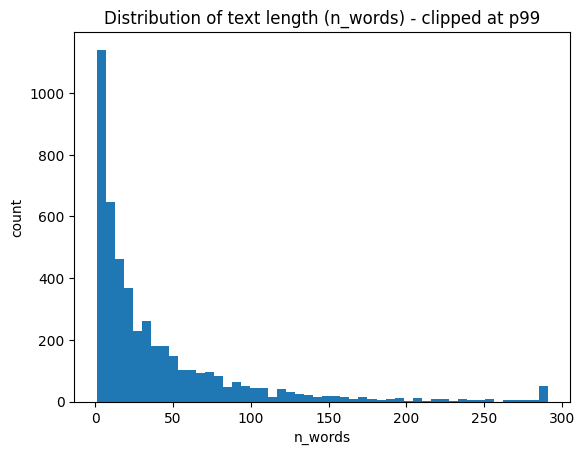

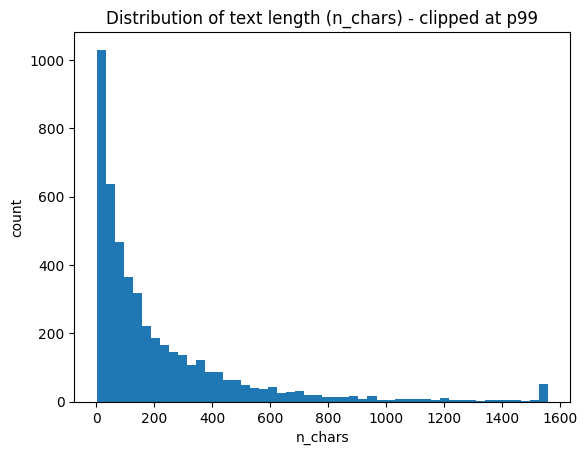

In [16]:
p99_chars = int(df["n_chars"].quantile(0.99))  # ép về int
p99_words = int(df["n_words"].quantile(0.99))

import matplotlib.pyplot as plt

plt.figure()
df["n_words"].clip(upper=p99_words).plot(kind="hist", bins=50)
plt.title("Distribution of text length (n_words) - clipped at p99")
plt.xlabel("n_words")
plt.ylabel("count")
plt.show()

plt.figure()
df["n_chars"].clip(upper=p99_chars).plot(kind="hist", bins=50)
plt.title("Distribution of text length (n_chars) - clipped at p99")
plt.xlabel("n_chars")
plt.ylabel("count")
plt.show()


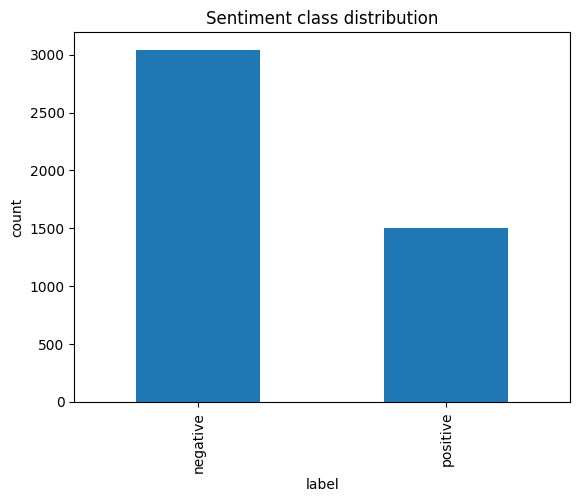

Class ratio (%):
label
negative    66.99
positive    33.01
Name: count, dtype: float64


In [20]:
label_order = ["negative", "positive"]

counts = df["label"].value_counts().reindex(label_order).fillna(0)

plt.figure()
counts.plot(kind="bar")
plt.title("Sentiment class distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

print("Class ratio (%):")
print((counts / counts.sum() * 100).round(2))


In [17]:
# Nếu chưa cài:
# !pip -q install langdetect

from langdetect import detect, LangDetectException

def safe_detect_lang(text: str, n_words: int) -> str:
    if not isinstance(text, str):
        return "unk"
    if n_words < 3:
        return "unk"
    try:
        return detect(text)
    except LangDetectException:
        return "unk"

# Nếu data lớn, nên sample để chạy nhanh:
# sample_df = df.sample(min(5000, len(df)), random_state=42).copy()
sample_df = df.copy()

sample_df["lang"] = sample_df.apply(lambda r: safe_detect_lang(r["text_clean"], r["n_words"]), axis=1)

lang_counts = sample_df["lang"].value_counts()
print("Top languages:")
print(lang_counts.head(30))


Top languages:
lang
en       2005
vi       1226
unk       322
ko        262
ja        153
de        125
ru         95
fr         90
th         35
id         30
es         29
it         29
ar         25
zh-cn      23
nl         16
pl         14
pt          9
tr          8
af          6
no          6
ca          4
he          4
tl          4
sk          3
da          3
el          3
hu          2
hr          2
fi          2
et          1
Name: count, dtype: int64


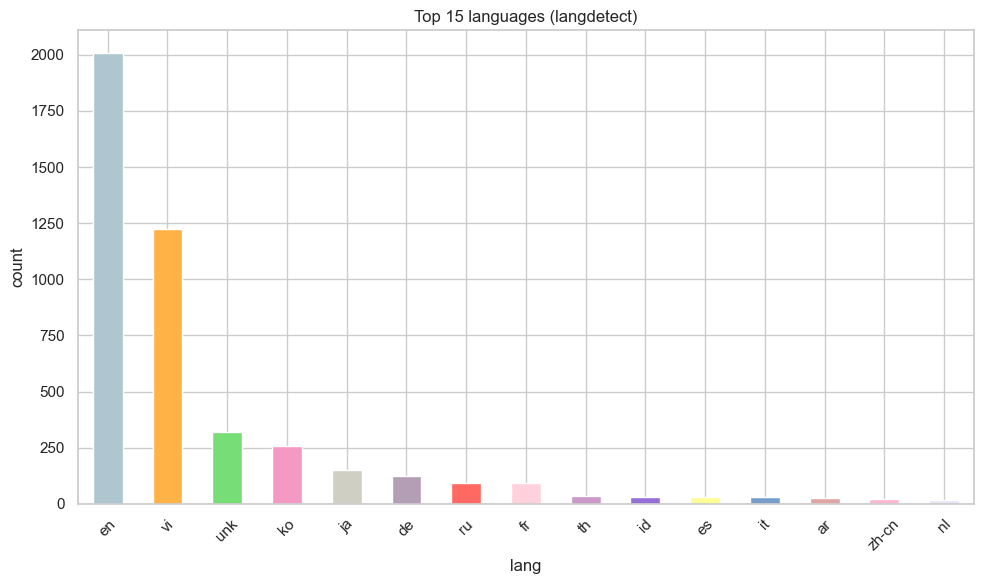

In [47]:
import matplotlib.pyplot as plt

TOP_N = 15
top_langs = lang_counts.head(TOP_N)

plt.figure(figsize=(10,6))
top_langs.plot(
    kind="bar",
    color=[
        "#AEC6CF", "#FFB347", "#77DD77", "#F49AC2", "#CFCFC4",
        "#B39EB5", "#FF6961", "#FFD1DC", "#CB99C9", "#966FD6",
        "#FDFD96", "#779ECB", "#DEA5A4", "#FFB7CE", "#E6E6FA"
    ]  # 15 màu pastel khác nhau
)

plt.title(f"Top {TOP_N} languages (langdetect)")
plt.xlabel("lang")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Crosstab (top languages):


label,negative,positive
lang,,
en,1635,370
vi,567,659
unk,124,198
ko,186,76
ja,103,50
de,95,30
ru,72,23
fr,71,19
th,27,8


<Figure size 640x480 with 0 Axes>

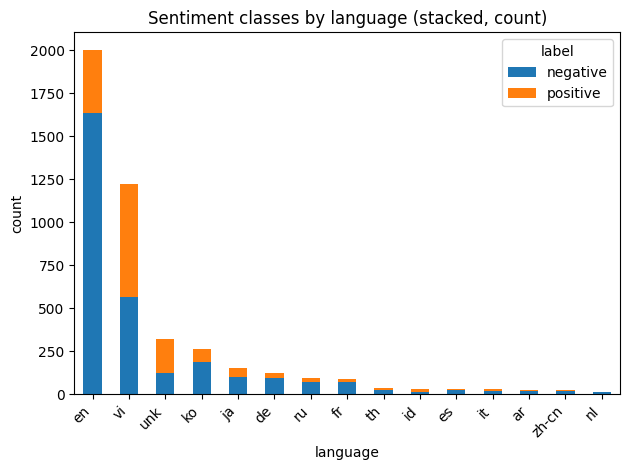

<Figure size 640x480 with 0 Axes>

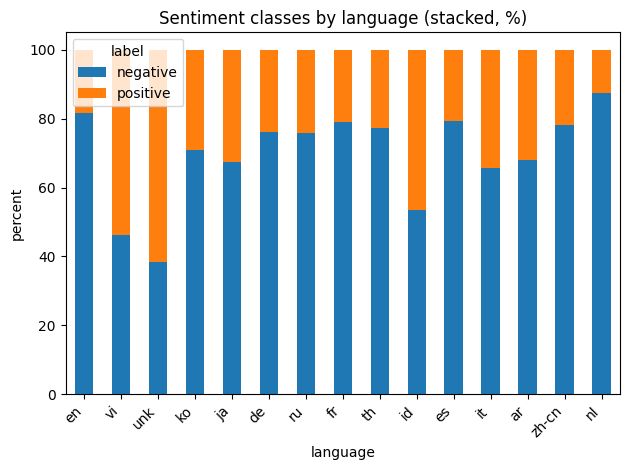

label,negative,positive
lang,,
en,81.55,18.45
vi,46.25,53.75
unk,38.51,61.49
ko,70.99,29.01
ja,67.32,32.68
de,76.00,24.00
ru,75.79,24.21
fr,78.89,21.11
th,77.14,22.86


In [23]:
# Bảng đếm: hàng=lang, cột=label
ct = pd.crosstab(sample_df["lang"], sample_df["label"]).reindex(columns=label_order).fillna(0)

# lấy top ngôn ngữ cho dễ nhìn
ct_top = ct.loc[top_langs.index]

print("Crosstab (top languages):")
display(ct_top)

# stacked bar theo count
plt.figure()
ct_top.plot(kind="bar", stacked=True)
plt.title("Sentiment classes by language (stacked, count)")
plt.xlabel("language")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# tỷ lệ theo ngôn ngữ (normalize theo hàng)
ct_ratio = (ct_top.T / ct_top.sum(axis=1)).T.fillna(0)

plt.figure()
(ct_ratio * 100).plot(kind="bar", stacked=True)
plt.title("Sentiment classes by language (stacked, %)")
plt.xlabel("language")
plt.ylabel("percent")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display((ct_ratio * 100).round(2))


n_words                            n_chars                         \
           count       mean median min  max   count        mean median min   
label                                                                        
negative    3042  49.215319   29.0   1  690    3042  270.785996  162.0   5   
positive    1499  28.692462   11.0   1  595    1499  152.216811   58.0   5   

                
           max  
label           
negative  3469  
positive  3562

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12276\1977574823.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_order, showfliers=False)


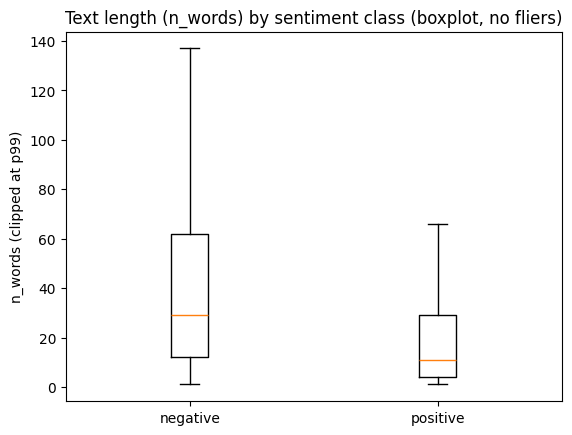

In [25]:
len_by_label = df.groupby("label")[["n_words","n_chars"]].agg(["count","mean","median","min","max"])
display(len_by_label)

# boxplot n_words theo label (giảm ảnh hưởng outliers)
p99 = df["n_words"].quantile(0.99)
data = [df.loc[df["label"] == lab, "n_words"].clip(upper=p99) for lab in label_order]

plt.figure()
plt.boxplot(data, labels=label_order, showfliers=False)
plt.title("Text length (n_words) by sentiment class (boxplot, no fliers)")
plt.ylabel("n_words (clipped at p99)")
plt.show()


## 1) Phân phối độ dài text (n_words / n_chars)

* Phân phối **lệch phải rất mạnh**: đa số bình luận **ngắn**, nhưng có một nhóm nhỏ **rất dài** (đuôi dài tới ~300 từ và ~1600 ký tự ở p99).  
* Đây là pattern “chuẩn” với review: nhiều câu ngắn kiểu “tệ”, “ok”, “đông”, xen kẽ vài review dài kể chi tiết.

**Hàm ý cho train**

* Khi tokenization, cần **truncation** và chọn `max_length` theo **p95/p99 token length** (thường 128 hoặc 256 hợp lý).  
* Không nên loại bỏ review ngắn; review ngắn vẫn mang sentiment mạnh.

---

## 2) Phân phối lớp cảm xúc (negative/neutral/positive)

* Dataset bị **mất cân bằng** khá rõ:  
  **negative nhiều nhất**, **positive đứng thứ hai**, **neutral ít nhất**.  
* Neutral (3 sao) thường ít → mô hình dễ học kém lớp này nếu không xử lý.

**Hàm ý cho train**

* Split cần **stratified theo label**.  
* Khi train nên dùng **class weights** hoặc báo cáo thêm **F1-macro** (đánh giá công bằng khi lệch lớp), không chỉ accuracy.

---

## 3) Ngôn ngữ trong dữ liệu

* `en` cao nhất, `vi` đứng thứ hai; sau đó là `unk`, rồi `ko`, `ja`, `de`, `ru`, `fr`, …  
* `unk` khá đáng kể, thường do:  
  * text **quá ngắn** (langdetect đoán không chắc)  
  * hoặc câu trộn nhiều ký tự/emoji/ký tự đặc biệt, hoặc chỉ tên riêng.

**Hàm ý**

* Dataset mang tính **đa ngôn ngữ rõ rệt** → lựa chọn **XLM-R** hợp lý cho baseline nâng cao.  
* Không nên kết luận chất lượng theo `unk`; coi `unk` là “không đủ tín hiệu để đoán ngôn ngữ”.

---

## 4) Lớp cảm xúc theo ngôn ngữ (stacked count & %)

* **English (en)**: tỷ lệ **negative cao**.  
* **Vietnamese (vi)**: tỷ lệ **positive cao hơn** so với en.  
* Các ngôn ngữ khác (ko/ja/…) ít mẫu nên % dao động mạnh.

**Hàm ý**

* Có khả năng “phân bố cảm xúc” khác nhau theo nhóm ngôn ngữ.  
* Khi đánh giá mô hình, nên báo cáo thêm **metric theo ngôn ngữ top (en, vi, ko)** để kiểm tra thiên lệch.

---

## 5) Độ dài theo lớp cảm xúc (boxplot)

* **Negative dài nhất**, Neutral ở giữa, **Positive ngắn nhất**.  
* Pattern thường gặp: phàn nàn thường giải thích dài; khen thường ngắn (“good”, “nice”).

**Hàm ý**

* Nếu chọn `max_length` quá thấp, có thể mất thông tin quan trọng của lớp negative.  
* Tuy nhiên đa số text ngắn, 128–256 token vẫn ổn.

---

### Kết luận nhanh cho phần EDA 

* Dữ liệu review **đa ngôn ngữ** (en, vi chiếm chủ đạo), có `unk` do text ngắn.  
* **Mất cân bằng nhãn** (negative > positive > neutral).  
* Độ dài text **lệch phải**: đa số ngắn, ít review rất dài.  
* Negative có xu hướng **dài hơn** positive → cần chọn `max_length` hợp lý và dùng metric phù hợp (F1-macro, per-language).

# Preprocessing

In [28]:
# Nếu df đã có cột "lang" thì bỏ qua cell này
# !pip -q install langdetect
from langdetect import detect, LangDetectException
import pandas as pd

def safe_detect_lang(text: str) -> str:
    # tránh đoán bừa với text quá ngắn
    if not isinstance(text, str):
        return "unk"
    if len(text.split()) < 3:
        return "unk"
    try:
        return detect(text)
    except LangDetectException:
        return "unk"

if "lang" not in df.columns:
    df["lang"] = df["text_clean"].astype("string").fillna("").apply(safe_detect_lang)

df["lang"].value_counts().head(20)


lang
en       2008
vi       1226
unk       322
ko        260
ja        153
de        125
ru         95
fr         92
th         35
id         31
es         29
it         29
ar         25
zh-cn      24
nl         17
pl         14
pt          8
tr          8
no          5
he          4
Name: count, dtype: int64

In [29]:
import numpy as np

lang_counts = df["lang"].value_counts(dropna=False)
lang_pct = (lang_counts / lang_counts.sum()).rename("pct")
lang_table = pd.concat([lang_counts.rename("count"), lang_pct], axis=1)

# sort theo count giảm dần và tính cumulative %
lang_table = lang_table.sort_values("count", ascending=False)
lang_table["cum_pct"] = lang_table["pct"].cumsum()

lang_table.head(30)


,count,pct,cum_pct
lang,,,
en,2008,0.442193,0.442193
vi,1226,0.269985,0.712178
unk,322,0.070909,0.783087
ko,260,0.057256,0.840344
ja,153,0.033693,0.874037
de,125,0.027527,0.901564
ru,95,0.020921,0.922484
fr,92,0.020260,0.942744
th,35,0.007708,0.950451


In [27]:
COVERAGE_TARGET = 0.98

keep_langs = lang_table[lang_table["cum_pct"] <= COVERAGE_TARGET].index.tolist()

# đảm bảo luôn có ít nhất 1 ngôn ngữ
if len(keep_langs) == 0:
    keep_langs = [lang_table.index[0]]

# Nếu muốn "đủ 90%" (bao gồm luôn ngôn ngữ làm vượt qua mốc), thêm 1 ngôn ngữ tiếp theo:
if lang_table.loc[keep_langs, "cum_pct"].max() < COVERAGE_TARGET and len(keep_langs) < len(lang_table):
    next_lang = lang_table.index[len(keep_langs)]
    keep_langs.append(next_lang)

print("Keep languages (cover ~90%+):", keep_langs)
print("Coverage:", round(lang_table.loc[keep_langs, "pct"].sum() * 100, 2), "%")


Keep languages (cover ~90%+): ['en', 'vi', 'unk', 'ko', 'ja', 'de', 'ru', 'fr', 'th', 'id', 'es', 'it', 'ar', 'zh-cn']
Coverage: 98.14 %


In [30]:
df_filtered = df[df["lang"].isin(keep_langs)].copy()

dropped = len(df) - len(df_filtered)
print("Before:", len(df))
print("After :", len(df_filtered))
print("Dropped:", dropped, f"({dropped/len(df)*100:.2f}%)")

# bảng các ngôn ngữ bị loại
drop_langs = [l for l in lang_table.index.tolist() if l not in keep_langs]
lang_dropped_table = lang_table.loc[drop_langs].copy()

print("Dropped languages:")
display(lang_dropped_table.head(50))


Before: 4541
After : 4454
Dropped: 87 (1.92%)
Dropped languages:


,count,pct,cum_pct
lang,,,
nl,17,0.003744,0.984585
pl,14,0.003083,0.987668
tr,8,0.001762,0.989430
pt,8,0.001762,0.991191
no,5,0.001101,0.992292
he,4,0.000881,0.993173
af,4,0.000881,0.994054
ca,4,0.000881,0.994935
sk,3,0.000661,0.995596


In [37]:
ASPECT_KEYWORDS_BY_LANG = {
  # ---------- English ----------
  "en": {
    "security_check": ["security", "security check", "screening", "x-ray"],
    "immigration_customs": ["immigration", "passport control", "customs", "visa"],
    "checkin_boarding": ["check-in", "check in", "boarding", "gate", "flight", "transfer", "connecting flight"],
    "queue_waiting": ["queue", "line", "waiting", "wait time", "crowded"],
    "staff_service": ["staff", "employee", "service", "rude", "helpful"],
    "cleanliness_toilets": ["toilet", "restroom", "bathroom", "clean", "dirty"],
    "price_value": ["price", "expensive", "overpriced", "cheap"],
    "food_beverage": ["food", "restaurant", "cafe", "coffee"],
    "wifi_internet": ["wifi", "wi-fi", "internet", "connection"],
    "baggage": ["baggage", "luggage", "bag", "lost baggage", "baggage claim"],
    "transport_parking": ["taxi", "grab", "bus", "parking", "traffic"],
    "signage_information": ["sign", "signage", "information", "direction", "wayfinding"],
  },

  # ---------- Vietnamese ----------
  "vi": {
    "security_check": ["an ninh", "soi chiếu", "kiểm tra an ninh", "x-ray"],
    "immigration_customs": ["nhập cảnh", "xuất cảnh", "hải quan", "hộ chiếu", "visa"],
    "checkin_boarding": ["check-in", "làm thủ tục", "lên máy bay", "cổng", "gate", "chuyến bay", "nối chuyến"],
    "queue_waiting": ["xếp hàng", "chờ", "đợi", "đông", "kẹt"],
    "staff_service": ["nhân viên", "thái độ", "phục vụ", "hỗ trợ", "thô lỗ"],
    "cleanliness_toilets": ["vệ sinh", "sạch", "bẩn", "nhà vệ sinh", "toilet", "wc"],
    "price_value": ["giá", "đắt", "rẻ", "chặt chém"],
    "food_beverage": ["đồ ăn", "ăn uống", "quán", "nhà hàng", "cà phê"],
    "wifi_internet": ["wifi", "internet", "mạng", "kết nối"],
    "baggage": ["hành lý", "vali", "ký gửi", "thất lạc", "băng chuyền"],
    "transport_parking": ["taxi", "grab", "xe buýt", "bãi xe", "gửi xe", "đậu xe"],
    "signage_information": ["chỉ dẫn", "biển", "bảng", "thông tin", "hướng dẫn"],
  },

  # ---------- Korean ----------
  "ko": {
    "security_check": ["보안", "보안 검사", "보안검색", "엑스레이"],
    "immigration_customs": ["입국심사", "출입국", "세관", "여권 검사"],
    "checkin_boarding": ["체크인", "탑승", "게이트", "보딩", "환승", "비행"],
    "queue_waiting": ["줄", "대기", "기다림", "대기 시간"],
    "staff_service": ["직원", "스태프", "서비스", "불친절", "친절"],
    "cleanliness_toilets": ["화장실", "청결", "깨끗", "더럽"],
    "price_value": ["가격", "비싸", "저렴", "바가지"],
    "food_beverage": ["음식", "식당", "카페", "커피"],
    "wifi_internet": ["와이파이", "wifi", "인터넷"],
    "baggage": ["수하물", "짐", "가방", "분실", "수하물 찾는 곳"],
    "transport_parking": ["택시", "버스", "주차", "교통"],
    "signage_information": ["안내", "표지판", "표시", "정보"],
  },

  # ---------- Japanese ----------
  "ja": {
    "security_check": ["セキュリティ", "保安検査", "手荷物検査", "X線"],
    "immigration_customs": ["入国審査", "出国審査", "税関", "パスポート"],
    "checkin_boarding": ["チェックイン", "搭乗", "ゲート", "便", "乗り継ぎ", "トランジット"],
    "queue_waiting": ["行列", "待ち", "待ち時間", "混雑"],
    "staff_service": ["スタッフ", "職員", "係員", "対応", "無愛想"],
    "cleanliness_toilets": ["トイレ", "清潔", "汚い", "きれい"],
    "price_value": ["価格", "高い", "安い", "割高"],
    "food_beverage": ["食事", "レストラン", "カフェ", "コーヒー"],
    "wifi_internet": ["Wi-Fi", "インターネット", "接続"],
    "baggage": ["荷物", "手荷物", "受託手荷物", "ロストバゲージ"],
    "transport_parking": ["タクシー", "バス", "駐車場", "交通"],
    "signage_information": ["案内", "標識", "看板", "表示", "情報"],
  },

  # ---------- German ----------
  "de": {
    "security_check": ["sicherheit", "sicherheitskontrolle", "gepäckkontrolle", "kontrolle"],
    "immigration_customs": ["passkontrolle", "einreise", "zoll", "immigration"],
    "checkin_boarding": ["check-in", "boarding", "gate", "flug", "umsteigen", "anschlussflug"],
    "queue_waiting": ["warteschlange", "wartezeit", "warten", "schlange"],
    "staff_service": ["personal", "mitarbeiter", "service", "unhöflich", "hilfsbereit"],
    "cleanliness_toilets": ["toilette", "wc", "sauber", "schmutzig"],
    "price_value": ["preis", "teuer", "günstig", "überteuert"],
    "food_beverage": ["essen", "restaurant", "café", "kaffee"],
    "wifi_internet": ["wlan", "wifi", "internet", "verbindung"],
    "baggage": ["gepäck", "koffer", "verlorenes gepäck", "gepäckausgabe"],
    "transport_parking": ["taxi", "bus", "parkplatz", "parken", "verkehr"],
    "signage_information": ["beschilderung", "schilder", "information", "wegweiser"],
  },

  # ---------- Russian ----------
  "ru": {
    "security_check": ["безопасность", "контроль безопасности", "досмотр", "рентген"],
    "immigration_customs": ["паспортный контроль", "иммиграция", "таможня", "паспорт"],
    "checkin_boarding": ["регистрация", "посадка", "гейт", "выход", "рейс", "пересадка"],
    "queue_waiting": ["очередь", "ожидание", "ждать", "время ожидания"],
    "staff_service": ["персонал", "сотрудники", "обслуживание", "грубо", "вежливый"],
    "cleanliness_toilets": ["туалет", "чисто", "грязно", "санузел"],
    "price_value": ["цена", "дорого", "дешево", "переплата"],
    "food_beverage": ["еда", "ресторан", "кафе", "кофе"],
    "wifi_internet": ["вайфай", "wifi", "интернет", "связь"],
    "baggage": ["багаж", "чемодан", "потерянный багаж", "выдача багажа"],
    "transport_parking": ["такси", "автобус", "парковка", "транспорт"],
    "signage_information": ["указатели", "таблички", "информация", "навигация"],
  },

  # ---------- French ----------
  "fr": {
    "security_check": ["sécurité", "contrôle de sécurité", "fouille", "scanner"],
    "immigration_customs": ["contrôle des passeports", "immigration", "douane", "passeport"],
    "checkin_boarding": ["enregistrement", "embarquement", "porte", "vol", "correspondance"],
    "queue_waiting": ["file", "attente", "temps d'attente", "bondé"],
    "staff_service": ["personnel", "employés", "service", "impoli", "aimable"],
    "cleanliness_toilets": ["toilettes", "propre", "sale", "wc"],
    "price_value": ["prix", "cher", "bon marché", "trop cher"],
    "food_beverage": ["nourriture", "restaurant", "café", "coffee"],
    "wifi_internet": ["wifi", "internet", "connexion"],
    "baggage": ["bagages", "valise", "bagage perdu", "retrait des bagages"],
    "transport_parking": ["taxi", "bus", "parking", "transport"],
    "signage_information": ["signalisation", "panneaux", "information", "indications"],
  },

  # ---------- Thai ----------
  "th": {
    "security_check": ["ความปลอดภัย", "ตรวจความปลอดภัย", "จุดตรวจ", "เอ็กซเรย์"],
    "immigration_customs": ["ตม", "ตรวจคนเข้าเมือง", "ศุลกากร", "พาสปอร์ต"],
    "checkin_boarding": ["เช็คอิน", "ขึ้นเครื่อง", "ประตู", "เกต", "เที่ยวบิน", "ต่อเครื่อง"],
    "queue_waiting": ["คิว", "รอ", "เวลารอ", "คนเยอะ"],
    "staff_service": ["พนักงาน", "บริการ", "หยาบคาย", "ช่วยเหลือ"],
    "cleanliness_toilets": ["ห้องน้ำ", "สะอาด", "สกปรก", "สุขา"],
    "price_value": ["ราคา", "แพง", "ถูก", "แพงมาก"],
    "food_beverage": ["อาหาร", "ร้านอาหาร", "คาเฟ่", "กาแฟ"],
    "wifi_internet": ["ไวไฟ", "wifi", "อินเทอร์เน็ต", "เน็ต"],
    "baggage": ["สัมภาระ", "กระเป๋า", "กระเป๋าเดินทาง", "กระเป๋าหาย", "รับกระเป๋า"],
    "transport_parking": ["แท็กซี่", "รถบัส", "ที่จอดรถ", "การเดินทาง", "รถติด"],
    "signage_information": ["ป้าย", "ป้ายบอกทาง", "ข้อมูล", "แผนที่"],
  },

  # ---------- Indonesian ----------
  "id": {
    "security_check": ["keamanan", "pemeriksaan keamanan", "security", "x-ray"],
    "immigration_customs": ["imigrasi", "pemeriksaan paspor", "bea cukai", "paspor"],
    "checkin_boarding": ["check-in", "boarding", "gate", "penerbangan", "transit", "sambungan"],
    "queue_waiting": ["antre", "antrian", "menunggu", "waktu tunggu"],
    "staff_service": ["staf", "petugas", "pelayanan", "kasar", "ramah"],
    "cleanliness_toilets": ["toilet", "kamar mandi", "bersih", "kotor"],
    "price_value": ["harga", "mahal", "murah", "terlalu mahal"],
    "food_beverage": ["makanan", "restoran", "kafe", "kopi"],
    "wifi_internet": ["wifi", "internet", "koneksi"],
    "baggage": ["bagasi", "koper", "barang", "bagasi hilang", "ambil bagasi"],
    "transport_parking": ["taksi", "bus", "parkir", "transportasi"],
    "signage_information": ["petunjuk", "papan", "informasi", "arah"],
  },

  # ---------- Spanish ----------
  "es": {
    "security_check": ["seguridad", "control de seguridad", "revisión", "escáner"],
    "immigration_customs": ["control de pasaportes", "inmigración", "aduana", "pasaporte"],
    "checkin_boarding": ["facturación", "check-in", "embarque", "puerta", "vuelo", "conexión"],
    "queue_waiting": ["cola", "fila", "espera", "tiempo de espera"],
    "staff_service": ["personal", "empleados", "servicio", "grosero", "amable"],
    "cleanliness_toilets": ["baño", "aseo", "limpio", "sucio"],
    "price_value": ["precio", "caro", "barato", "muy caro"],
    "food_beverage": ["comida", "restaurante", "cafetería", "café"],
    "wifi_internet": ["wifi", "internet", "conexión"],
    "baggage": ["equipaje", "maleta", "equipaje perdido", "recogida de equipaje"],
    "transport_parking": ["taxi", "autobús", "aparcamiento", "transporte"],
    "signage_information": ["señalización", "carteles", "información", "indicaciones"],
  },

  # ---------- Italian ----------
  "it": {
    "security_check": ["sicurezza", "controllo di sicurezza", "controllo", "ispezione"],
    "immigration_customs": ["controllo passaporti", "immigrazione", "dogana", "passaporto"],
    "checkin_boarding": ["check-in", "imbarco", "gate", "volo", "coincidenza", "transito"],
    "queue_waiting": ["coda", "attesa", "tempo di attesa", "fila"],
    "staff_service": ["personale", "addetti", "servizio", "scortese", "gentile"],
    "cleanliness_toilets": ["bagno", "toilette", "pulito", "sporco"],
    "price_value": ["prezzo", "caro", "economico", "troppo caro"],
    "food_beverage": ["cibo", "ristorante", "bar", "caffè"],
    "wifi_internet": ["wifi", "internet", "connessione"],
    "baggage": ["bagagli", "valigia", "bagaglio smarrito", "ritiro bagagli"],
    "transport_parking": ["taxi", "autobus", "parcheggio", "trasporto"],
    "signage_information": ["segnaletica", "cartelli", "informazioni", "indicazioni"],
  },

  # ---------- Arabic ----------
  "ar": {
    "security_check": ["الأمن", "تفتيش", "فحص أمني", "تفتيش أمني"],
    "immigration_customs": ["الجوازات", "تفتيش جوازات", "الهجرة", "الجمارك", "جواز"],
    "checkin_boarding": ["تسجيل الدخول", "تسجيل", "بوابة", "الصعود للطائرة", "رحلة", "ترانزيت"],
    "queue_waiting": ["طابور", "انتظار", "وقت الانتظار", "ازدحام"],
    "staff_service": ["موظفون", "طاقم", "خدمة", "وقح", "غير متعاون", "متعاون"],
    "cleanliness_toilets": ["دورة المياه", "حمام", "نظيف", "قذر"],
    "price_value": ["سعر", "غالي", "رخيص", "مبالغ فيه"],
    "food_beverage": ["طعام", "مطعم", "قهوة", "مقهى"],
    "wifi_internet": ["واي فاي", "wifi", "إنترنت", "انترنت"],
    "baggage": ["أمتعة", "حقيبة", "شنطة", "ضياع الأمتعة", "استلام الأمتعة"],
    "transport_parking": ["تاكسي", "حافلة", "موقف سيارات", "مواصلات", "ازدحام"],
    "signage_information": ["لافتات", "إرشادات", "معلومات", "لوحات"],
  },

  # ---------- Simplified Chinese ----------
  "zh-cn": {
    "security_check": ["安检", "安全检查", "保安", "x光"],
    "immigration_customs": ["入境", "入境检查", "出境", "海关", "护照检查"],
    "checkin_boarding": ["值机", "登机", "登机口", "航班", "转机", "中转"],
    "queue_waiting": ["排队", "等候", "等待", "拥挤"],
    "staff_service": ["工作人员", "服务", "态度", "粗鲁", "热情"],
    "cleanliness_toilets": ["厕所", "卫生间", "干净", "脏"],
    "price_value": ["价格", "贵", "便宜", "太贵"],
    "food_beverage": ["食物", "餐厅", "咖啡", "饭"],
    "wifi_internet": ["wifi", "wi-fi", "无线网", "网络", "网速"],
    "baggage": ["行李", "行李箱", "托运", "行李丢失", "取行李"],
    "transport_parking": ["出租车", "公交", "停车场", "交通", "打车"],
    "signage_information": ["指示牌", "标识", "信息", " 안내"],  # nếu có tiếng Hàn lẫn, bạn có thể xoá "안내"
  },

  # ---------- Unknown language fallback ----------
  # unk: KHÔNG tạo riêng; dùng en+vi để match cho câu ngắn / khó detect
  "unk": "fallback_en_vi"
}


In [35]:
keep_langs = ['en', 'vi', 'unk', 'ko', 'ja', 'de', 'ru', 'fr', 'th', 'id', 'es', 'it', 'ar', 'zh-cn']

df_filtered = df[df["lang"].isin(keep_langs)].copy()

print("Before:", len(df))
print("After :", len(df_filtered))
print("Coverage kept:", round(len(df_filtered)/len(df)*100, 2), "%")
df_filtered["lang"].value_counts().head(20)


Before: 4541
After : 4454
Coverage kept: 98.08 %


lang
en       2008
vi       1226
unk       322
ko        260
ja        153
de        125
ru         95
fr         92
th         35
id         31
es         29
it         29
ar         25
zh-cn      24
Name: count, dtype: int64

In [43]:
df_filtered.columns

Index(['title', 'url', 'rating', 'author', 'review_id', 'text', 'text_raw',
       'text_clean', 'label', 'label_id', 'n_chars', 'n_words', 'lang'],
      dtype='object')

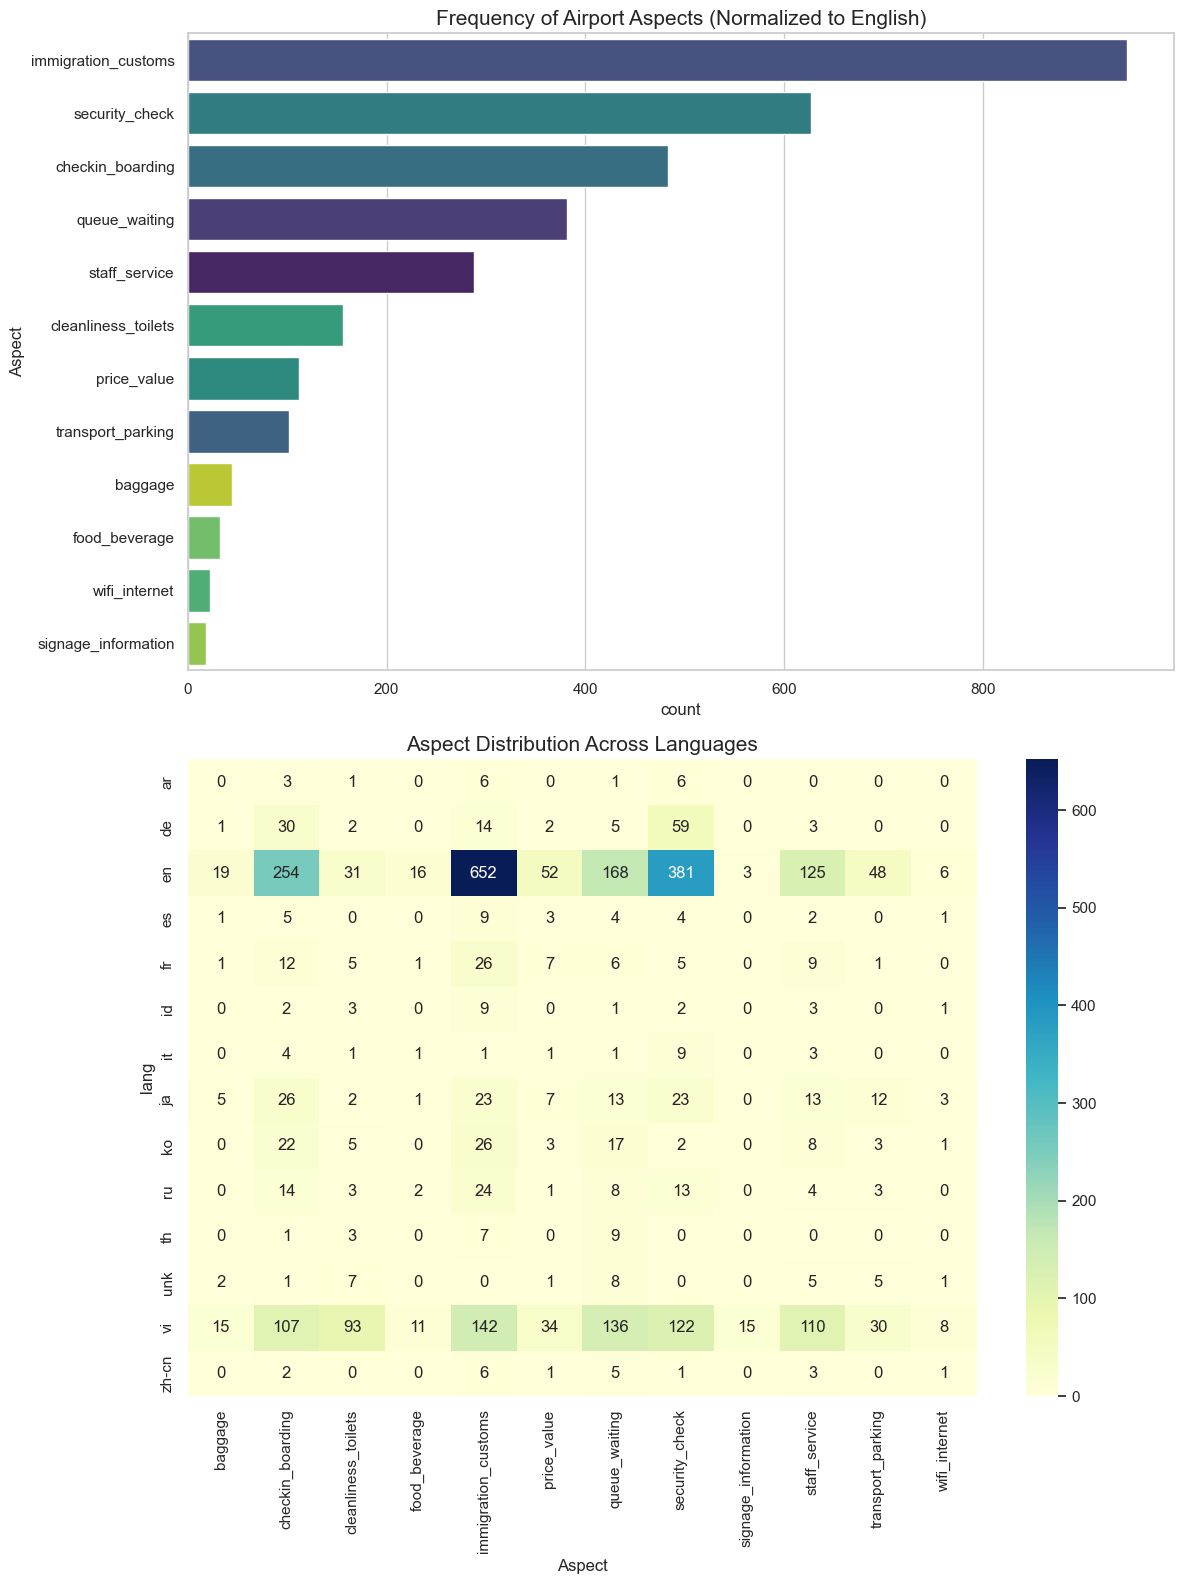

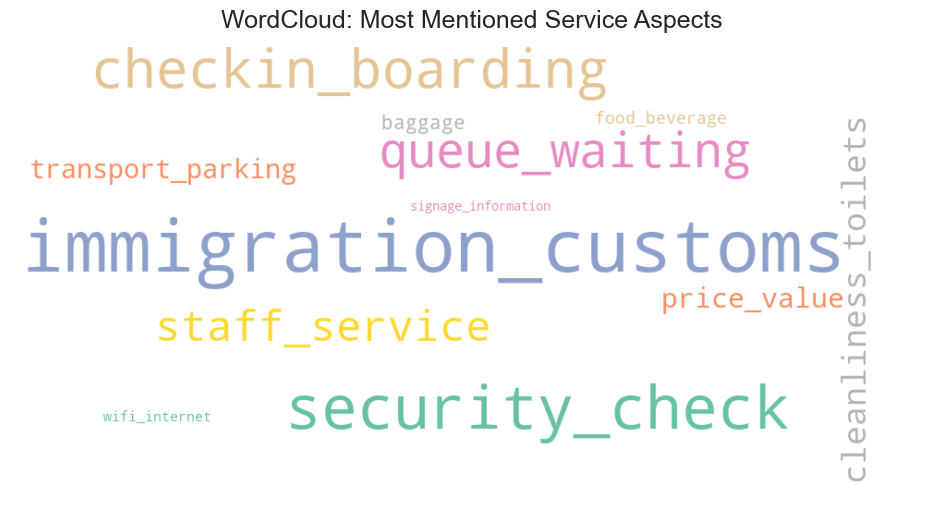

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Định nghĩa bộ từ điển Aspect (Dùng để map đa ngôn ngữ về Tiếng Anh)
ASPECT_KEYWORDS_BY_LANG = {
    "en": {"security_check": ["security", "security check", "screening", "x-ray"], "immigration_customs": ["immigration", "passport control", "customs", "visa"], "checkin_boarding": ["check-in", "check in", "boarding", "gate", "flight", "transfer", "connecting flight"], "queue_waiting": ["queue", "line", "waiting", "wait time", "crowded"], "staff_service": ["staff", "employee", "service", "rude", "helpful"], "cleanliness_toilets": ["toilet", "restroom", "bathroom", "clean", "dirty"], "price_value": ["price", "expensive", "overpriced", "cheap"], "food_beverage": ["food", "restaurant", "cafe", "coffee"], "wifi_internet": ["wifi", "wi-fi", "internet", "connection"], "baggage": ["baggage", "luggage", "bag", "lost baggage", "baggage claim"], "transport_parking": ["taxi", "grab", "bus", "parking", "traffic"], "signage_information": ["sign", "signage", "information", "direction", "wayfinding"]},
    "vi": {"security_check": ["an ninh", "soi chiếu", "kiểm tra an ninh", "x-ray"], "immigration_customs": ["nhập cảnh", "xuất cảnh", "hải quan", "hộ chiếu", "visa"], "checkin_boarding": ["check-in", "làm thủ tục", "lên máy bay", "cổng", "gate", "chuyến bay", "nối chuyến"], "queue_waiting": ["xếp hàng", "chờ", "đợi", "đông", "kẹt"], "staff_service": ["nhân viên", "thái độ", "phục vụ", "hỗ trợ", "thô lỗ"], "cleanliness_toilets": ["vệ sinh", "sạch", "bẩn", "nhà vệ sinh", "toilet", "wc"], "price_value": ["giá", "đắt", "rẻ", "chặt chém"], "food_beverage": ["đồ ăn", "ăn uống", "quán", "nhà hàng", "cà phê"], "wifi_internet": ["wifi", "internet", "mạng", "kết nối"], "baggage": ["hành lý", "vali", "ký gửi", "thất lạc", "băng chuyền"], "transport_parking": ["taxi", "grab", "xe buýt", "bãi xe", "gửi xe", "đậu xe"], "signage_information": ["chỉ dẫn", "biển", "bảng", "thông tin", "hướng dẫn"]},
    "ko": {"security_check": ["보안", "보안 검사", "보안검색", "엑스레이"], "immigration_customs": ["입국심사", "출입국", "세관", "여권 검사"], "checkin_boarding": ["체크인", "탑승", "게이트", "보딩", "환승", "비행"], "queue_waiting": ["줄", "대기", "기다림", "대기 시간"], "staff_service": ["직원", "스태프", "서비스", "불친절", "친절"], "cleanliness_toilets": ["화장실", "청결", "깨끗", "더럽"], "price_value": ["가격", "비싸", "저렴", "바가지"], "food_beverage": ["음식", "식당", "카페", "커피"], "wifi_internet": ["와이파이", "wifi", "인터넷"], "baggage": ["수하물", "짐", "가방", "분실", "수하물 찾는 곳"], "transport_parking": ["택시", "버스", "주차", "교통"], "signage_information": ["안내", "표지판", "표시", "정보"]},
    "ja": {"security_check": ["セキュリティ", "保安検査", "手荷物検査", "X線"], "immigration_customs": ["入国審査", "出国審査", "税関", "パスポート"], "checkin_boarding": ["チェックイン", "搭乗", "ゲート", "便", "乗り継ぎ", "トランジット"], "queue_waiting": ["行列", "待ち", "待ち時間", "混雑"], "staff_service": ["スタッフ", "職員", "係員", "対応", "無愛想"], "cleanliness_toilets": ["トイレ", "清潔", "汚い", "きれい"], "price_value": ["価格", "高い", "安い", "割高"], "food_beverage": ["食事", "レストラン", "カフェ", "コーヒー"], "wifi_internet": ["Wi-Fi", "インターネット", "接続"], "baggage": ["荷物", "手荷物", "受託手荷物", "ロストバゲージ"], "transport_parking": ["タクシー", "バス", "駐車場", "交通"], "signage_information": ["案内", "標識", "看板", "表示", "情報"]},
    "de": {"security_check": ["sicherheit", "sicherheitskontrolle", "gepäckkontrolle", "kontrolle"], "immigration_customs": ["passkontrolle", "einreise", "zoll", "immigration"], "checkin_boarding": ["check-in", "boarding", "gate", "flug", "umsteigen", "anschlussflug"], "queue_waiting": ["warteschlange", "wartezeit", "warten", "schlange"], "staff_service": ["personal", "mitarbeiter", "service", "unhöflich", "hilfsbereit"], "cleanliness_toilets": ["toilette", "wc", "sauber", "schmutzig"], "price_value": ["preis", "teuer", "günstig", "überteuert"], "food_beverage": ["essen", "restaurant", "café", "kaffee"], "wifi_internet": ["wlan", "wifi", "internet", "verbindung"], "baggage": ["gepäck", "koffer", "verlorenes gepäck", "gepäckausgabe"], "transport_parking": ["taxi", "bus", "parkplatz", "parken", "verkehr"], "signage_information": ["beschilderung", "schilder", "information", "wegweiser"]},
    "ru": {"security_check": ["безопасность", "контроль безопасности", "досмотр", "рентген"], "immigration_customs": ["паспортный контроль", "иммиграция", "таможня", "паспорт"], "checkin_boarding": ["регистрация", "посадка", "гейт", "выход", "рейс", "пересадка"], "queue_waiting": ["очередь", "ожидание", "ждать", "время ожидания"], "staff_service": ["персонал", "сотрудники", "обслуживание", "грубо", "вежливый"], "cleanliness_toilets": ["туалет", "чисто", "грязно", "санузел"], "price_value": ["цена", "дорого", "дешево", "переплата"], "food_beverage": ["еда", "ресторан", "кафе", "кофе"], "wifi_internet": ["вайфай", "wifi", "интернет", "связь"], "baggage": ["багаж", "чемодан", "потерянный багаж", "выдача багажа"], "transport_parking": ["такси", "автобус", "парковка", "транспорт"], "signage_information": ["указатели", "таблички", "информация", "навигация"]},
    "fr": {"security_check": ["sécurité", "contrôle de sécurité", "fouille", "scanner"], "immigration_customs": ["contrôle des passeports", "immigration", "douane", "passeport"], "checkin_boarding": ["enregistrement", "embarquement", "porte", "vol", "correspondance"], "queue_waiting": ["file", "attente", "temps d'attente", "bondé"], "staff_service": ["personnel", "employés", "service", "impoli", "aimable"], "cleanliness_toilets": ["toilettes", "propre", "sale", "wc"], "price_value": ["prix", "cher", "bon marché", "trop cher"], "food_beverage": ["nourriture", "restaurant", "café", "coffee"], "wifi_internet": ["wifi", "internet", "connexion"], "baggage": ["bagages", "valise", "bagage perdu", "retrait des bagages"], "transport_parking": ["taxi", "bus", "parking", "transport"], "signage_information": ["signalisation", "panneaux", "information", "indications"]},
    "th": {"security_check": ["ความปลอดภัย", "ตรวจความปลอดภัย", "จุดตรวจ", "เอ็กซเรย์"], "immigration_customs": ["ตม", "ตรวจคนเข้าเมือง", "ศุลกากร", "พาสปอร์ต"], "checkin_boarding": ["เช็คอิน", "ขึ้นเครื่อง", "ประตู", "เกต", "เที่ยวบิน", "ต่อเครื่อง"], "queue_waiting": ["คิว", "รอ", "เวลารอ", "คนเยอะ"], "staff_service": ["พนักงาน", "บริการ", "หยาบคาย", "ช่วยเหลือ"], "cleanliness_toilets": ["ห้องน้ำ", "สะอาด", "สกปรก", "สุขา"], "price_value": ["ราคา", "แพง", "ถูก", "แพงมาก"], "food_beverage": ["อาหาร", "ร้านอาหาร", "คาเฟ่", "กาแฟ"], "wifi_internet": ["ไวไฟ", "wifi", "อินเทอร์เน็ต", "เน็ต"], "baggage": ["สัมภาระ", "กระเป๋า", "กระเป๋าเดินทาง", "กระเป๋าหาย", "รับกระเป๋า"], "transport_parking": ["แท็กซี่", "รถบัส", "ที่จอดรถ", "การเดินทาง", "รถติด"], "signage_information": ["ป้าย", "ป้ายบอกทาง", "ข้อมูล", "แผนที่"]},
    "id": {"security_check": ["keamanan", "pemeriksaan keamanan", "security", "x-ray"], "immigration_customs": ["imigrasi", "pemeriksaan paspor", "bea cukai", "paspor"], "checkin_boarding": ["check-in", "boarding", "gate", "penerbangan", "transit", "sambungan"], "queue_waiting": ["antre", "antrian", "menunggu", "waktu tunggu"], "staff_service": ["staf", "petugas", "pelayanan", "kasar", "ramah"], "cleanliness_toilets": ["toilet", "kamar mandi", "bersih", "kotor"], "price_value": ["harga", "mahal", "murah", "terlalu mahal"], "food_beverage": ["makanan", "restoran", "kafe", "kopi"], "wifi_internet": ["wifi", "internet", "koneksi"], "baggage": ["bagasi", "koper", "barang", "bagasi hilang", "ambil bagasi"], "transport_parking": ["taksi", "bus", "parkir", "transportasi"], "signage_information": ["petunjuk", "papan", "informasi", "arah"]},
    "es": {"security_check": ["seguridad", "control de seguridad", "revisión", "escáner"], "immigration_customs": ["control de pasaportes", "inmigración", "aduana", "pasaporte"], "checkin_boarding": ["facturación", "check-in", "embarque", "puerta", "vuelo", "conexión"], "queue_waiting": ["cola", "fila", "espera", "tiempo de espera"], "staff_service": ["personal", "empleados", "servicio", "grosero", "amable"], "cleanliness_toilets": ["baño", "aseo", "limpio", "sucio"], "price_value": ["precio", "caro", "barato", "muy caro"], "food_beverage": ["comida", "restaurante", "cafetería", "café"], "wifi_internet": ["wifi", "internet", "conexión"], "baggage": ["equipaje", "maleta", "equipaje perdido", "recogida de equipaje"], "transport_parking": ["taxi", "autobús", "aparcamiento", "transporte"], "signage_information": ["señalización", "carteles", "información", "indicaciones"]},
    "it": {"security_check": ["sicurezza", "controllo di sicurezza", "controllo", "ispezione"], "immigration_customs": ["controllo passaporti", "immigrazione", "dogana", "passaporto"], "checkin_boarding": ["check-in", "imbarco", "gate", "volo", "coincidenza", "transito"], "queue_waiting": ["coda", "attesa", "tempo di attesa", "fila"], "staff_service": ["personale", "addetti", "servizio", "scortese", "gentile"], "cleanliness_toilets": ["bagno", "toilette", "pulito", "sporco"], "price_value": ["prezzo", "caro", "economico", "troppo caro"], "food_beverage": ["cibo", "ristorante", "bar", "caffè"], "wifi_internet": ["wifi", "internet", "connessione"], "baggage": ["bagagli", "valigia", "bagaglio smarrito", "ritiro bagagli"], "transport_parking": ["taxi", "autobus", "parcheggio", "trasporto"], "signage_information": ["segnaletica", "cartelli", "informazioni", "indicazioni"]},
    "ar": {"security_check": ["الأمن", "تفتيش", "فحص أمني", "تفتيش أمني"], "immigration_customs": ["الجوازات", "تفتيش جوازات", "الهجرة", "الجمارك", "جواز"], "checkin_boarding": ["تسجيل الدخول", "تسجيل", "بوابة", "الصعود للطائرة", "رحلة", "ترانزيت"], "queue_waiting": ["طابور", "انتظار", "وقت الانتظار", "ازدحام"], "staff_service": ["موظفون", "طاقم", "خدمة", "وقح", "غير متعاون", "متعاون"], "cleanliness_toilets": ["دورة المياه", "حمام", "نظيف", "قذر"], "price_value": ["سعر", "غالي", "رخيص", "مبالغ فيه"], "food_beverage": ["طعام", "مطعم", "قهوة", "مقهى"], "wifi_internet": ["واي فاي", "wifi", "إنترنت", "انترنت"], "baggage": ["أمتعة", "حقيبة", "شنطة", "ضياع الأمتعة", "استلام الأمتعة"], "transport_parking": ["تاكسي", "حافلة", "موقف سيارات", "مواصلات", "ازدحام"], "signage_information": ["لافتات", "إرشادات", "معلومات", "لوحات"]},
    "zh-cn": {"security_check": ["安检", "安全检查", "保安", "x光"], "immigration_customs": ["入境", "入境检查", "出境", "海关", "护照检查"], "checkin_boarding": ["值机", "登机", "登机口", "航班", "转机", "中转"], "queue_waiting": ["排队", "等候", "等待", "拥挤"], "staff_service": ["工作人员", "服务", "态度", "粗鲁", "热情"], "cleanliness_toilets": ["厕所", "卫生间", "干净", "脏"], "price_value": ["价格", "贵", "便宜", "太贵"], "food_beverage": ["食物", "餐厅", "咖啡", "饭"], "wifi_internet": ["wifi", "wi-fi", "无线网", "网络", "网速"], "baggage": ["行李", "行李箱", "托运", "行李丢失", "取行李"], "transport_parking": ["出租车", "公交", "停车场", "交通", "打车"], "signage_information": ["指示牌", "标识", "信息"]}
}

# 2. Hàm xử lý logic: Ánh xạ từ text_clean sang Aspect tiếng Anh
def map_aspect(row):
    text = str(row['text_clean']).lower()
    lang = row['lang']
    
    # Xác định các bộ từ điển cần quét
    if lang in ASPECT_KEYWORDS_BY_LANG and lang != 'unk':
        dicts_to_check = [ASPECT_KEYWORDS_BY_LANG[lang]]
    else:
        # Fallback cho 'unk' hoặc ngôn ngữ lạ: Quét cả Anh và Việt
        dicts_to_check = [ASPECT_KEYWORDS_BY_LANG['en'], ASPECT_KEYWORDS_BY_LANG['vi']]
        
    for d in dicts_to_check:
        for aspect_en, keywords in d.items():
            for kw in keywords:
                if kw.lower() in text:
                    return aspect_en
    return "others"

# 3. Thực thi gán nhãn Aspect vào DataFrame
df_filtered['Aspect'] = df_filtered.apply(map_aspect, axis=1)

# 4. Trực quan hóa
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# Lọc bỏ 'others' để biểu đồ trực quan hơn
df_plot = df_filtered[df_filtered['Aspect'] != 'others']

# --- BIỂU ĐỒ 1: Tần suất Aspect (Bar Chart) ---
if not df_plot.empty:
    order = df_plot['Aspect'].value_counts().index
    sns.countplot(data=df_plot, y='Aspect', order=order, hue='Aspect', legend=False, palette='viridis', ax=axes[0])
    axes[0].set_title("Frequency of Airport Aspects (Normalized to English)", fontsize=15)
    
    # --- BIỂU ĐỒ 2: Heatmap Aspect vs Language ---
    pivot_data = pd.crosstab(df_plot['lang'], df_plot['Aspect'])
    sns.heatmap(pivot_data, annot=True, cmap="YlGnBu", fmt='d', ax=axes[1])
    axes[1].set_title("Aspect Distribution Across Languages", fontsize=15)
else:
    print("Warning: No aspects matched to display in charts.")

plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ 3: WordCloud ---
if not df_plot.empty:
    # WordCloud dựa trên tần suất các key tiếng Anh
    aspect_counts = df_plot['Aspect'].value_counts().to_dict()
    wc = WordCloud(width=1000, height=500, background_color='white', colormap='Set2').generate_from_frequencies(aspect_counts)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud: Most Mentioned Service Aspects", fontsize=18)
    plt.show()

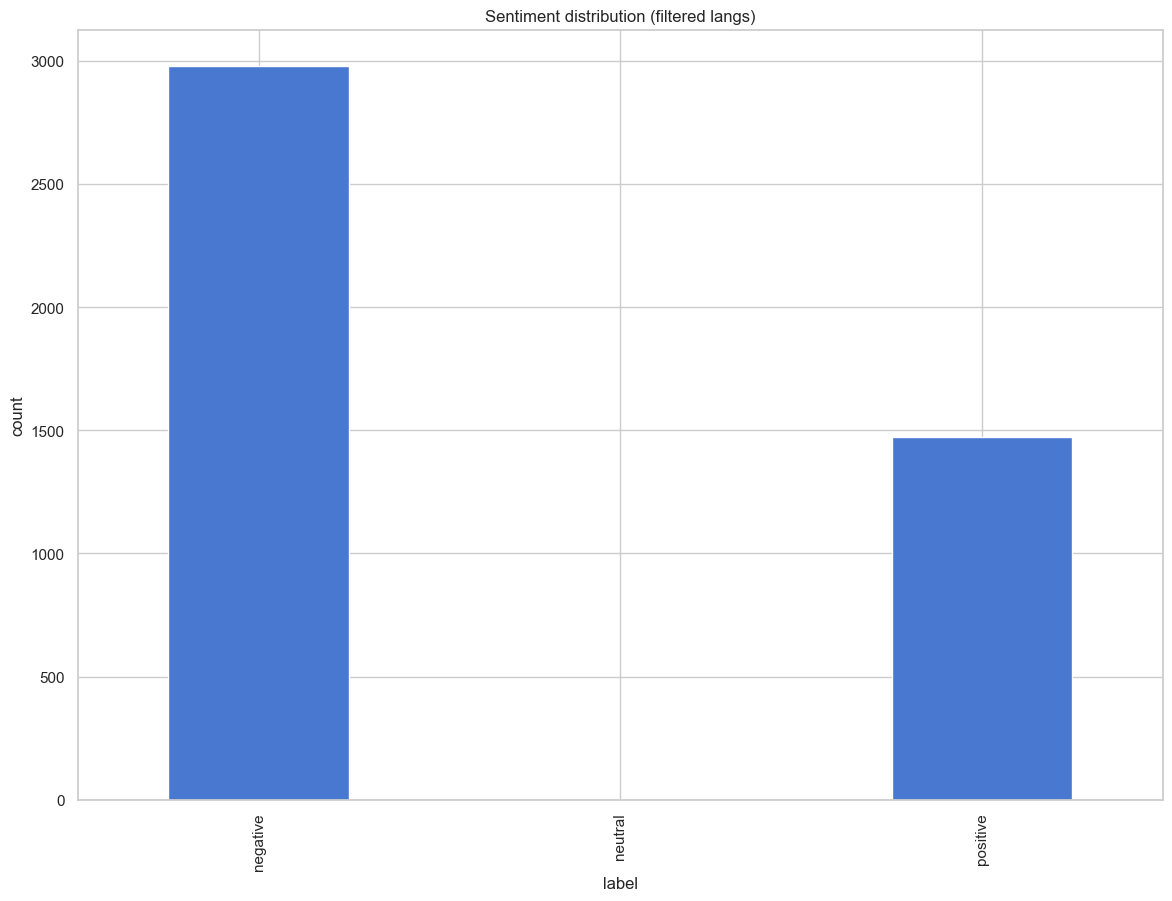

Class ratio (%):
label
negative    66.88
neutral      0.00
positive    33.12
Name: count, dtype: float64


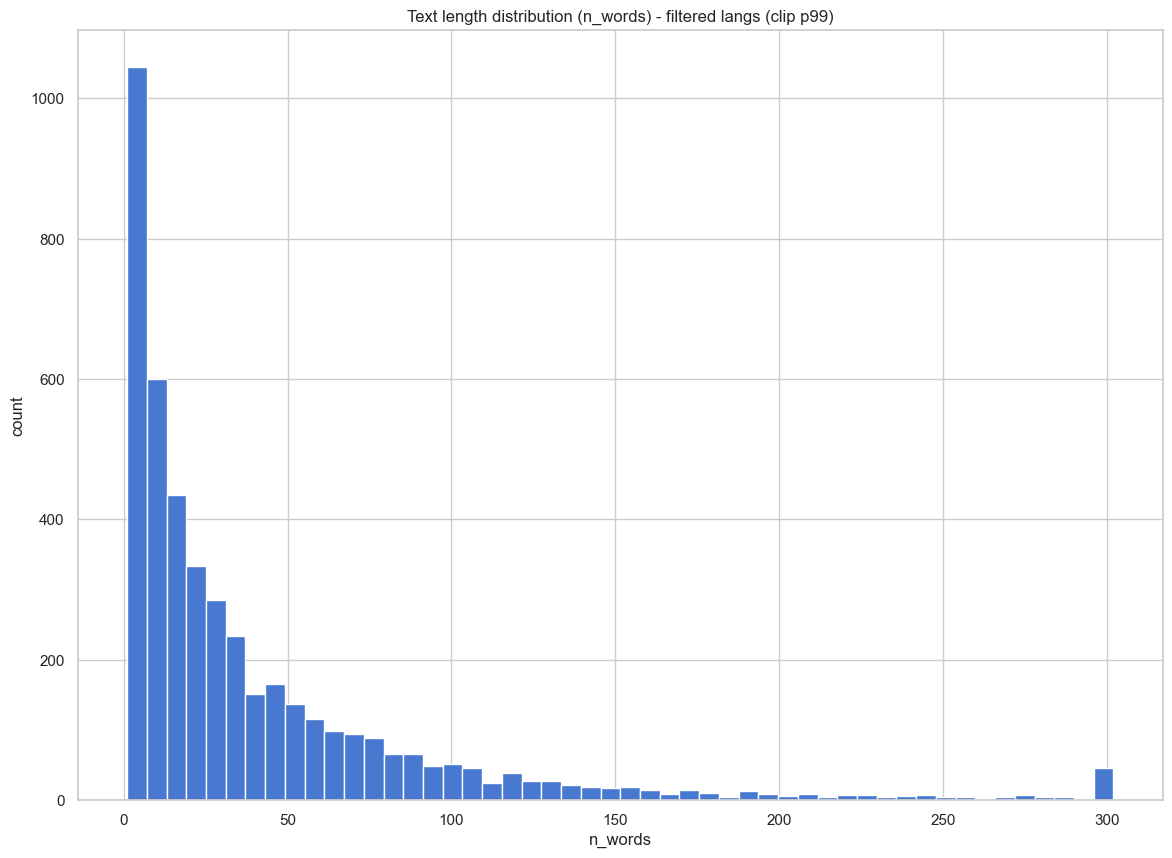

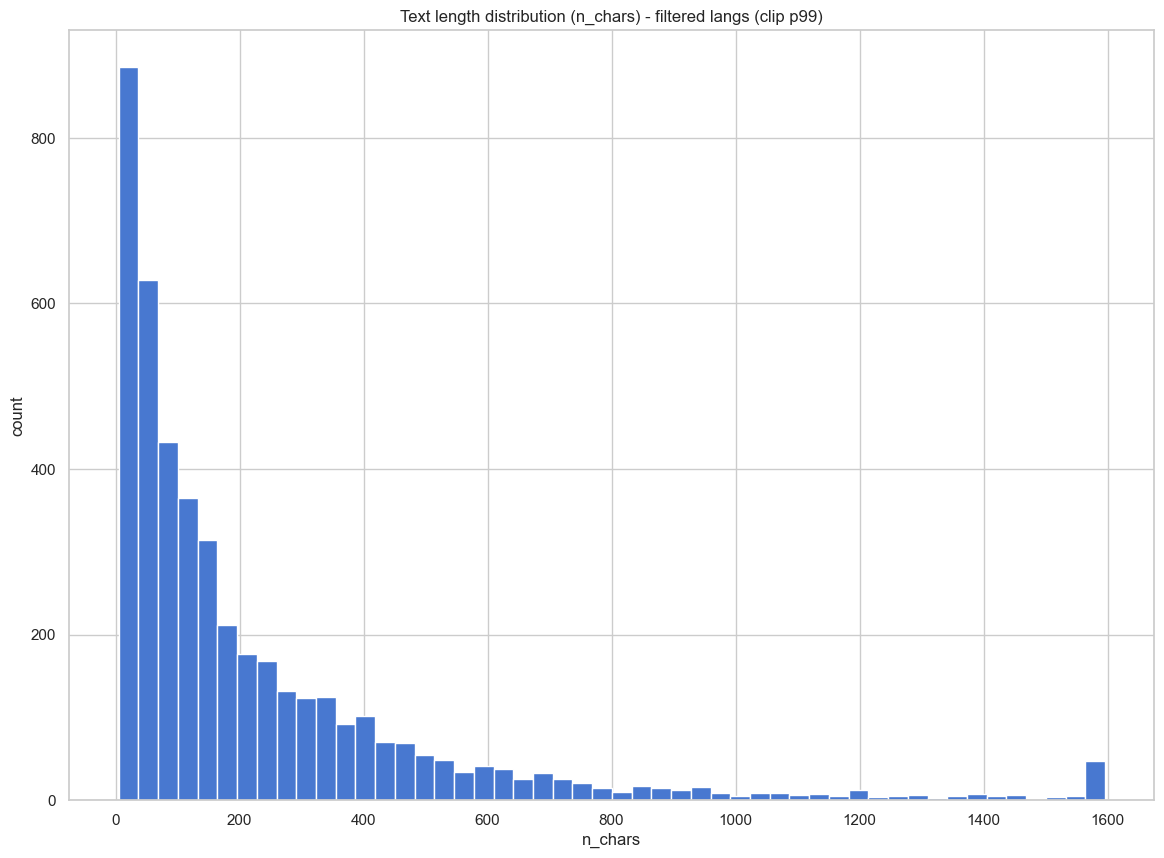

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# độ dài
df_filtered["n_words"] = df_filtered["text_clean"].astype("string").fillna("").str.split().apply(len)
df_filtered["n_chars"] = df_filtered["text_clean"].astype("string").fillna("").str.len()

# label distribution
label_order = ["negative", "neutral", "positive"]
counts = df_filtered["label"].value_counts().reindex(label_order).fillna(0)

plt.figure()
counts.plot(kind="bar")
plt.title("Sentiment distribution (filtered langs)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

print("Class ratio (%):")
print((counts / counts.sum() * 100).round(2))

# length hist (clip p99)
p99_words = int(df_filtered["n_words"].quantile(0.99))
p99_chars = int(df_filtered["n_chars"].quantile(0.99))

plt.figure()
df_filtered["n_words"].clip(upper=p99_words).plot(kind="hist", bins=50)
plt.title("Text length distribution (n_words) - filtered langs (clip p99)")
plt.xlabel("n_words")
plt.ylabel("count")
plt.show()

plt.figure()
df_filtered["n_chars"].clip(upper=p99_chars).plot(kind="hist", bins=50)
plt.title("Text length distribution (n_chars) - filtered langs (clip p99)")
plt.xlabel("n_chars")
plt.ylabel("count")
plt.show()


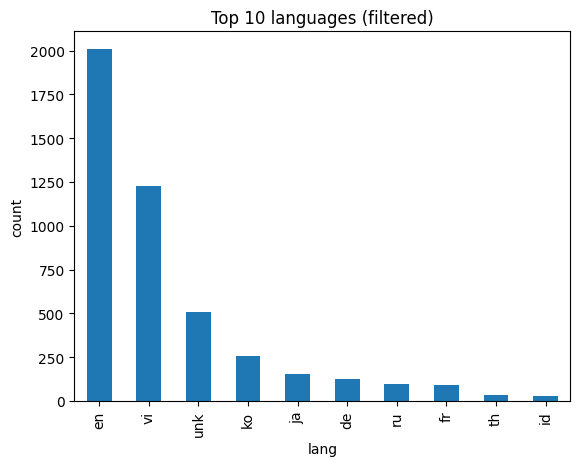

<Figure size 640x480 with 0 Axes>

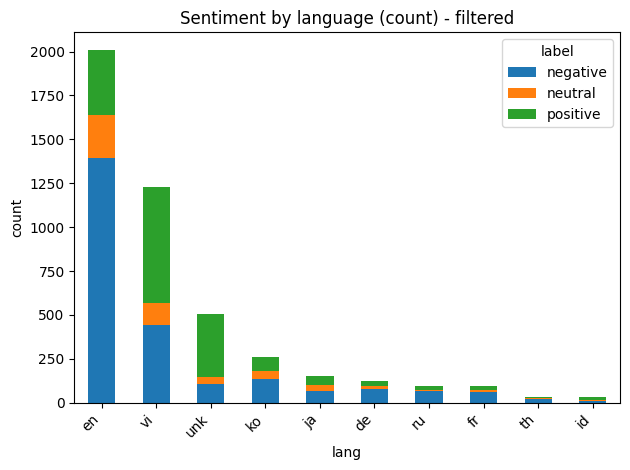

<Figure size 640x480 with 0 Axes>

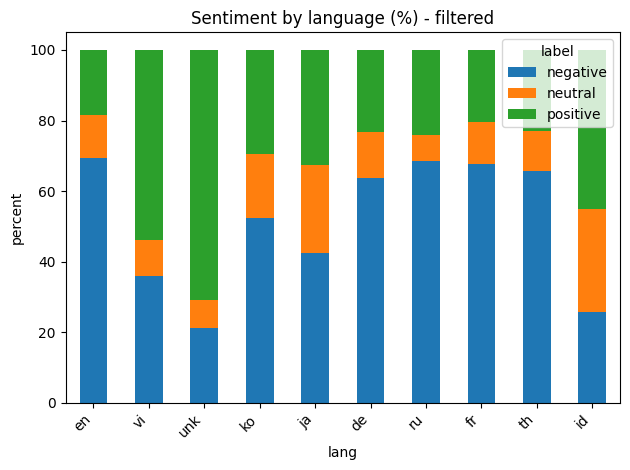

In [32]:
lang_counts = df_filtered["lang"].value_counts()
TOP_N = 10

plt.figure()
lang_counts.head(TOP_N).plot(kind="bar")
plt.title(f"Top {TOP_N} languages (filtered)")
plt.xlabel("lang")
plt.ylabel("count")
plt.show()

ct = pd.crosstab(df_filtered["lang"], df_filtered["label"]).reindex(columns=label_order).fillna(0)
ct_top = ct.loc[lang_counts.head(TOP_N).index]

plt.figure()
ct_top.plot(kind="bar", stacked=True)
plt.title("Sentiment by language (count) - filtered")
plt.xlabel("lang")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ct_ratio = (ct_top.T / ct_top.sum(axis=1)).T.fillna(0)
plt.figure()
(ct_ratio * 100).plot(kind="bar", stacked=True)
plt.title("Sentiment by language (%) - filtered")
plt.xlabel("lang")
plt.ylabel("percent")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [33]:
import re

# sentence split
SENT_SPLIT = re.compile(r"[\.!\?\n\r]+")

def split_sentences(text: str, min_len=2):
    if not isinstance(text, str):
        return []
    parts = [s.strip() for s in SENT_SPLIT.split(text) if s and s.strip()]
    parts = [s for s in parts if len(s) >= min_len]
    return parts

def normalize_for_match(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

# helper lấy keywords theo lang + fallback
def get_kw_for_lang(lang: str):
    if lang == "unk":
        base_en = ASPECT_KEYWORDS_BY_LANG.get("en", {})
        base_vi = ASPECT_KEYWORDS_BY_LANG.get("vi", {})
        merged = {}
        for asp in set(base_en) | set(base_vi):
            merged[asp] = sorted(set(base_en.get(asp, []) + base_vi.get(asp, [])), key=len, reverse=True)
        return merged

    lang_kw = ASPECT_KEYWORDS_BY_LANG.get(lang, {})
    base_en = ASPECT_KEYWORDS_BY_LANG.get("en", {})
    merged = {}
    for asp in set(lang_kw) | set(base_en):
        merged[asp] = sorted(set(lang_kw.get(asp, []) + base_en.get(asp, [])), key=len, reverse=True)
    return merged

def match_aspects(sentence: str, kw_dict: dict):
    s_norm = normalize_for_match(sentence)
    hits = []
    for asp, kws in kw_dict.items():
        hit_kws = [kw for kw in kws if normalize_for_match(kw) in s_norm]
        if hit_kws:
            hits.append((asp, hit_kws))
    return hits


In [34]:
records = []
for _, row in df_filtered.iterrows():
    review_id = row["review_id"]
    label_id = row["label_id"]
    label = row["label"]
    lang = row["lang"]

    kw_dict = get_kw_for_lang(lang)
    sents = split_sentences(str(row["text_clean"]))

    for sid, sent in enumerate(sents):
        hits = match_aspects(sent, kw_dict)
        if not hits:
            continue
        for asp, hit_kws in hits:
            records.append({
                "review_id": review_id,
                "lang": lang,
                "sent_id": sid,
                "sentence": sent,
                "aspect": asp,
                "hit_keywords": ", ".join(hit_kws[:10]),
                "label_id": label_id,
                "label": label,
            })

absa_df = pd.DataFrame(records)
print("ABSA rows:", len(absa_df))
absa_df.head(10)


ABSA rows: 11185


,review_id,lang,sent_id,sentence,aspect,hit_keywords,label_id,label
0,https://www.google.com/maps/reviews/data=!4m8!...,vi,0,Cảng hàng không quốc tế Tân Sơn Nhất phục vụ q...,staff_service,phục vụ,2,positive
1,https://www.google.com/maps/reviews/data=!4m8!...,vi,0,Cảng hàng không quốc tế Tân Sơn Nhất phục vụ q...,cleanliness_toilets,sạch,2,positive
2,https://www.google.com/maps/reviews/data=!4m8!...,ko,0,여행의 마지막 기억을 최악으로 망쳐버리는 식료품 및 기념품 가격,price_value,가격,0,negative
3,https://www.google.com/maps/reviews/data=!4m8!...,ko,1,ㅋ (젤리 한봉지에 3만원이에요) 시내에 비하면 4배 이상의 가격이 책정되어있습니다...,price_value,"가격, 비싸",0,negative
4,https://www.google.com/maps/reviews/data=!4m8!...,ko,2,나라 특성이라지만 마지막 기억을 더 좋게 만들어 줄 순 없었을까요 꼭 뭐든 밖에서 ...,queue_waiting,줄,0,negative
5,https://www.google.com/maps/reviews/data=!4m8!...,en,1,Stupid immigration,immigration_customs,immigration,0,negative
6,https://www.google.com/maps/reviews/data=!4m8!...,en,0,So busy airport,transport_parking,bus,2,positive
7,https://www.google.com/maps/reviews/data=!4m8!...,vi,0,Nhà ga T3 Tân Sơn Nhất mang lại cảm giác hiện ...,price_value,giá,2,positive
8,https://www.google.com/maps/reviews/data=!4m8!...,vi,2,"Khu vực làm thủ tục được bố trí khoa học, bảng...",signage_information,"chỉ dẫn, bảng",2,positive
9,https://www.google.com/maps/reviews/data=!4m8!...,vi,2,"Khu vực làm thủ tục được bố trí khoa học, bảng...",checkin_boarding,"làm thủ tục, check-in, cổng",2,positive


In [35]:
# phân phối aspect
print("Aspect distribution:")
display(absa_df["aspect"].value_counts())

# phân phối nhãn trong absa
print("Label distribution in ABSA:")
display(absa_df["label"].value_counts())

# aspect x label
ct2 = pd.crosstab(absa_df["aspect"], absa_df["label"]).reindex(columns=label_order).fillna(0)
display(ct2)

# tỷ lệ câu được giữ
total_sents = df_filtered["text_clean"].apply(lambda x: len(split_sentences(str(x)))).sum()
kept_sents = absa_df[["review_id","sent_id"]].drop_duplicates().shape[0]
print("Total sentences:", int(total_sents))
print("Kept sentences:", int(kept_sents))
print("Kept ratio:", round(kept_sents / max(1,total_sents), 4))


Aspect distribution:


aspect
queue_waiting          2076
checkin_boarding       1865
immigration_customs    1733
staff_service          1375
transport_parking       810
security_check          756
price_value             623
baggage                 529
cleanliness_toilets     494
food_beverage           456
signage_information     326
wifi_internet           153
Name: count, dtype: int64

Label distribution in ABSA:


label
negative    7251
positive    2492
neutral     1453
Name: count, dtype: int64

label,negative,neutral,positive
aspect,,,
baggage,377,48,104
checkin_boarding,1226,235,404
cleanliness_toilets,161,80,253
food_beverage,239,76,141
immigration_customs,1250,232,251
price_value,412,92,119
queue_waiting,1390,242,444
security_check,513,105,138
signage_information,200,47,79


Total sentences: 14383
Kept sentences: 7355
Kept ratio: 0.5114


## 1) Aspect distribution

**Top aspect**  
- queue_waiting (2076)  
- checkin_boarding (1865)  
- immigration_customs (1733)  
- staff_service (1375)  

→ Đây là 4 chủ đề “đúng reality” của review sân bay (đông – thủ tục – nhập cảnh – thái độ nhân viên).

**Nhóm thấp nhất**  
- wifi_internet (153)  
- signage_information (326)  
- food_beverage (456)  
- cleanliness_toilets (494)  

→ Dễ hiểu: người ta ít nhắc wifi/biển chỉ dẫn hơn so với chờ đợi/thủ tục.

**Hàm ý**  
- Dataset ABSA không cân bằng theo aspect (top aspect gấp ~13.6 lần wifi).  
- Khi báo cáo theo aspect, cần chú ý: wifi có ít mẫu → metric dao động lớn.

---

## 2) Label distribution (mất cân bằng nhãn)

- negative: 7251 (~64.4%)  
- positive: 2492 (~22.1%)  
- neutral: 1453 (~12.9%)  

→ Rất lệch về negative (khớp với review sân bay: dễ bị than phiền hơn).

**Hàm ý**  
- Không nên chỉ dùng accuracy; cần F1-macro và F1 theo từng lớp.  
- Khi train XLM-R, nên dùng class weights hoặc oversampling (đặc biệt cho neutral/positive).

---

## 3) Crosstab aspect × label

**“Cực âm” nhất**  
- immigration_customs: 1250/1733 → ~72% negative  
- staff_service: 980/1375 → ~71% negative  
- price_value: 412/623 → ~66% negative  
- security_check: 513/756 → ~68% negative  
- queue_waiting: 1390/2076 → ~67% negative  

✅ Đúng thực tế: thủ tục nhập cảnh, thái độ, giá, an ninh, xếp hàng thường bị phàn nàn.

**“Ít âm hơn / cân bằng hơn”**  
- cleanliness_toilets: positive 253 vs negative 161 → positive > negative  
- transport_parking: negative 428, neutral 152, positive 230 → neutral khá cao  

**Hàm ý (quan trọng cho weak label)**  
- Vì nhãn cảm xúc gán theo rating toàn review, có thể sai lệch ở câu/aspect level.  
- Ví dụ: review 1 sao nhưng có câu khen “toilet sạch” → câu đó bị gán negative dù nội dung positive.  
- Cleanliness_toilets có positive cao hơn negative là dấu hiệu tốt: keyword match bắt được câu khen thật, dù weak label còn nhiễu.

---

## 4) Kept ratio

- Kept ratio = 0.5114 (~51%)  
- Tổng câu sau tách: 14,383  
- Câu gán ≥1 aspect: 7,355  
- ~49% câu bị loại vì không match keyword  

**Nhận xét**  
- 51% là mức khá ổn cho keyword-based tagging.  
- Nếu kept ratio quá thấp (<25%) → keyword list yếu.  
- Nếu quá cao (>80%) → keyword quá chung → nhiễu.  
- Ở mức này, cân bằng giữa coverage và precision.

**Hàm ý**  
- Muốn tăng coverage: mở rộng keyword cho aspect ít dữ liệu (wifi/signage/food), thêm từ viết tắt/ngôn ngữ đời thường (vd: “wc”, “rest room”, “wlan”, “gate”, “boarding pass”, “passport”...).  
- Muốn tăng precision: dùng match có ràng buộc (vd: “gate” đi kèm “boarding/flight” để tránh false positive).

---

## 5) Kết luận chất lượng dataset ABSA

✅ Điểm mạnh:  
- Aspect phân bố hợp lý với ngữ cảnh sân bay.  
- Kept ratio hợp lý (pipeline chạy tốt).  
- Có đủ mẫu để train (tổng record ABSA: 11,196 samples).  

⚠️ Vấn đề cần xử lý trước train:  
- Class imbalance (negative quá nhiều).  
- Aspect imbalance (wifi/signage ít).  
- Weak label noise (label theo rating toàn review → sai ở sentence/aspect level).

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Folder lưu ảnh (tuỳ chọn)
OUT_DIR = "charts"
os.makedirs(OUT_DIR, exist_ok=True)

# Theme chung
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Palette cho sentiment
SENT_COLORS = {
    "negative": "#E74C3C",  # đỏ
    "neutral":  "#F39C12",  # cam
    "positive": "#2ECC71",  # xanh lá
}
label_order = ["negative", "neutral", "positive"]

# Nếu bạn đã có aspect_vi rồi thì bỏ đoạn mapping này
ASPECT_VI = {
    "queue_waiting": "Xếp hàng & chờ đợi",
    "checkin_boarding": "Check-in & lên máy bay",
    "immigration_customs": "Nhập cảnh & hải quan",
    "staff_service": "Nhân viên & phục vụ",
    "transport_parking": "Di chuyển & bãi xe",
    "security_check": "An ninh & soi chiếu",
    "price_value": "Giá cả & chặt chém",
    "baggage": "Hành lý & băng chuyền",
    "cleanliness_toilets": "Vệ sinh & nhà vệ sinh",
    "food_beverage": "Đồ ăn & thức uống",
    "signage_information": "Biển chỉ dẫn & thông tin",
    "wifi_internet": "WiFi & Internet",
}
if "aspect_vi" not in absa_df.columns:
    absa_df = absa_df.copy()
    absa_df["aspect_vi"] = absa_df["aspect"].map(lambda x: ASPECT_VI.get(x, x))

def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)


In [56]:
!pip install plotly kaleido wordcloud

In [57]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import plotly.express as px
import plotly.graph_objects as go

# =========================
# 1) PALETTE: "Aviation Modern"
# =========================
PALETTE = {
    "positive": "#00C897",   # mint
    "negative": "#FF5252",   # coral red
    "neutral":  "#F1C40F",   # sunny yellow
    "accent":   "#2C3E50",   # dark navy
    "muted":    "#BDBDBD",
    "bg":       "#FFFFFF"
}
LABEL_ORDER = ["negative", "neutral", "positive"]

# =========================
# 2) Matplotlib style đẹp
# =========================
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.edgecolor": "#DDDDDD",
    "axes.titlecolor": PALETTE["accent"],
    "axes.labelcolor": PALETTE["accent"],
    "xtick.color": PALETTE["accent"],
    "ytick.color": PALETTE["accent"],
    "grid.color": "#EAEAEA",
    "grid.linestyle": "-",
    "grid.alpha": 0.6,
})

# =========================
# 3) Chuẩn hoá df
# =========================
df = absa_df.copy()

# đảm bảo label đầy đủ
df["label"] = df["label"].astype("string").str.strip().str.lower()
df = df[df["label"].isin(LABEL_ORDER)].copy()

# aspect_vi (nếu chưa có thì dùng aspect)
if "aspect_vi" not in df.columns:
    df["aspect_vi"] = df["aspect"].astype("string")

# sentence length
df["sent_len_words"] = df["sentence"].astype("string").fillna("").str.split().apply(len)
df["sent_len_chars"] = df["sentence"].astype("string").fillna("").str.len()

# =========================
# 4) Bảng tổng hợp theo aspect
# =========================
ct = pd.crosstab(df["aspect_vi"], df["label"]).reindex(columns=LABEL_ORDER).fillna(0)

aspect_total = ct.sum(axis=1)
pos_rate = (ct["positive"] / aspect_total).replace([np.inf, np.nan], 0)
neg_rate = (ct["negative"] / aspect_total).replace([np.inf, np.nan], 0)
neu_rate = (ct["neutral"]  / aspect_total).replace([np.inf, np.nan], 0)

net_score = (pos_rate - neg_rate)   # [-1..1] (dương = tốt)

aspect_summary = pd.DataFrame({
    "aspect_vi": ct.index,
    "n_total": aspect_total.values.astype(int),
    "negative": ct["negative"].values.astype(int),
    "neutral":  ct["neutral"].values.astype(int),
    "positive": ct["positive"].values.astype(int),
    "neg_rate": neg_rate.values,
    "neu_rate": neu_rate.values,
    "pos_rate": pos_rate.values,
    "net_score": net_score.values,
}).sort_values("n_total", ascending=False)

aspect_summary.head()


,aspect_vi,n_total,negative,neutral,positive,neg_rate,neu_rate,pos_rate,net_score
10,Xếp hàng & chờ đợi,2076,1390,242,444,0.669557,0.116570,0.213873,-0.455684
2,Check-in & lên máy bay,1865,1226,235,404,0.657373,0.126005,0.216622,-0.440751
7,Nhập cảnh & hải quan,1733,1250,232,251,0.721293,0.133872,0.144836,-0.576457
6,Nhân viên & phục vụ,1375,980,121,274,0.712727,0.088000,0.199273,-0.513455
3,Di chuyển & bãi xe,810,428,152,230,0.528395,0.187654,0.283951,-0.244444


In [58]:
overall = df["label"].value_counts().reindex(LABEL_ORDER).fillna(0)
total_samples = int(overall.sum())
unique_reviews = int(df["review_id"].nunique()) if "review_id" in df.columns else None

fig = go.Figure(data=[go.Pie(
    labels=LABEL_ORDER,
    values=overall.values,
    hole=0.6,
    marker=dict(colors=[PALETTE[l] for l in LABEL_ORDER], line=dict(color="white", width=2)),
    textinfo="percent+label",
)])

center_text = f"<b>{total_samples:,}</b><br>ABSA samples"
fig.update_layout(
    title=dict(text="Tổng quan cảm xúc (Donut)", font=dict(color=PALETTE["accent"])),
    annotations=[dict(text=center_text, x=0.5, y=0.5, font_size=16, showarrow=False)],
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"]),
    margin=dict(l=20, r=20, t=60, b=20)
)
fig.show()


c:\Anaconda\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [59]:
neg_pct = overall["negative"] / total_samples * 100
pos_pct = overall["positive"] / total_samples * 100
nss = (pos_pct - neg_pct)  # Net Sentiment Score (%)

most_complained = aspect_summary.sort_values("negative", ascending=False).iloc[0]["aspect_vi"]

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=unique_reviews if unique_reviews is not None else total_samples,
    title={"text": "Tổng Review (unique)"},
    domain={"row": 0, "column": 0}
))
fig.add_trace(go.Indicator(
    mode="number",
    value=pos_pct,
    number={"suffix": "%", "valueformat": ".1f"},
    title={"text": "Tỷ lệ Tích cực"},
    domain={"row": 0, "column": 1}
))
fig.add_trace(go.Indicator(
    mode="number",
    value=neg_pct,
    number={"suffix": "%", "valueformat": ".1f"},
    title={"text": "Tỷ lệ Tiêu cực"},
    domain={"row": 0, "column": 2}
))
fig.add_trace(go.Indicator(
    mode="number",
    value=nss,
    number={"suffix": " pts", "valueformat": ".1f"},
    title={"text": "NSS (Pos% - Neg%)"},
    domain={"row": 0, "column": 3}
))

fig.update_layout(
    grid={"rows": 1, "columns": 4, "pattern": "independent"},
    title="Big Number Cards — Thực trạng tổng quan",
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"]),
    margin=dict(l=20, r=20, t=60, b=20)
)
fig.show()

print("Khía cạnh bị phàn nàn nhiều nhất:", most_complained)


Khía cạnh bị phàn nàn nhiều nhất: Xếp hàng & chờ đợi


In [60]:
fig = px.treemap(
    aspect_summary,
    path=["aspect_vi"],
    values="n_total",
    color="net_score",
    color_continuous_scale=["#FF5252", "#F1C40F", "#00C897"],  # đỏ -> vàng -> xanh
    range_color=(-1, 1),
    title="Treemap — Mức độ được nhắc tới & mức tốt/xấu (net_score)"
)
fig.update_layout(
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"]),
    margin=dict(l=10, r=10, t=60, b=10)
)
fig.show()


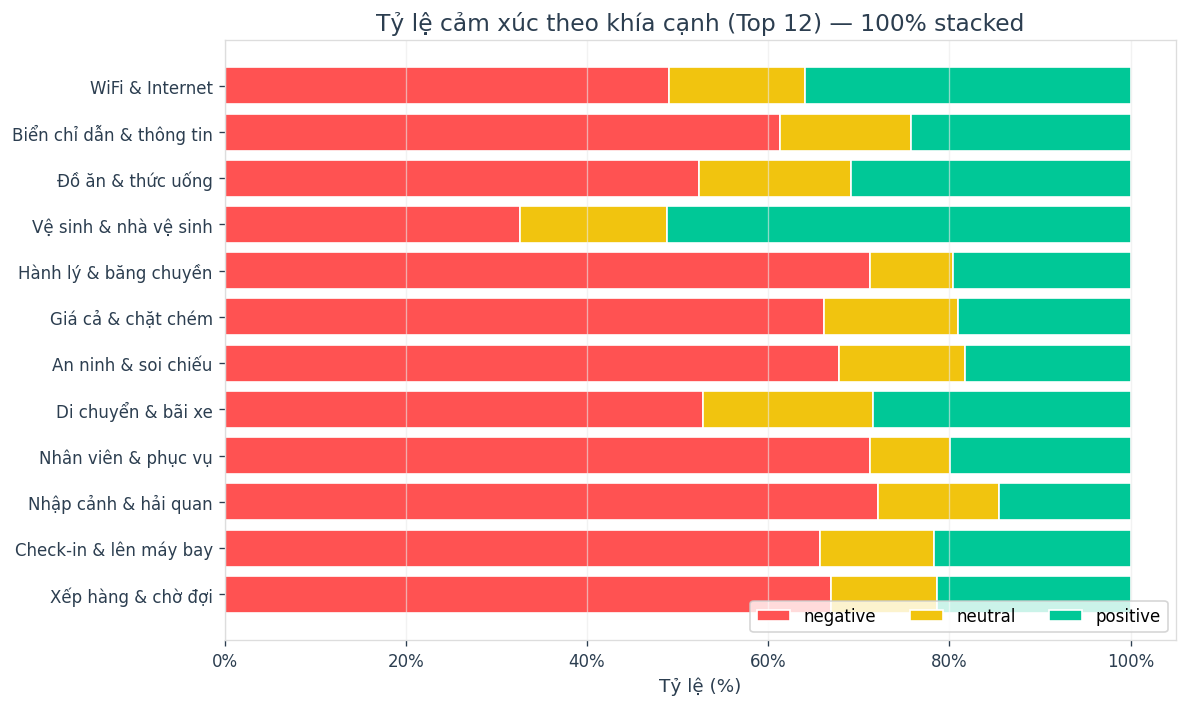

In [61]:
TOP_N = 12
top_aspects = aspect_summary.head(TOP_N)["aspect_vi"].tolist()

ct_top = ct.loc[top_aspects]
ratio = (ct_top.T / ct_top.sum(axis=1)).T.fillna(0)

plt.figure(figsize=(10, 6))
left = np.zeros(len(ratio))

for lab in LABEL_ORDER:
    vals = ratio[lab].values
    plt.barh(ratio.index, vals, left=left, color=PALETTE[lab], edgecolor="white", label=lab)
    left += vals

plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.title(f"Tỷ lệ cảm xúc theo khía cạnh (Top {TOP_N}) — 100% stacked")
plt.xlabel("Tỷ lệ (%)")
plt.grid(axis="x")
plt.legend(ncol=3, loc="lower right")
plt.tight_layout()
plt.show()


In [62]:
rad = aspect_summary.sort_values("pos_rate", ascending=False).head(10).copy()
cats = rad["aspect_vi"].tolist()
vals = rad["pos_rate"].tolist()
vals += vals[:1]
cats += cats[:1]

fig = go.Figure()
fig.add_trace(go.Scatterpolar(
    r=vals,
    theta=cats,
    fill="toself",
    name="Positive rate",
    line=dict(color=PALETTE["positive"])
))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Radar — Positive rate theo khía cạnh (Top 10)",
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"])
)
fig.show()


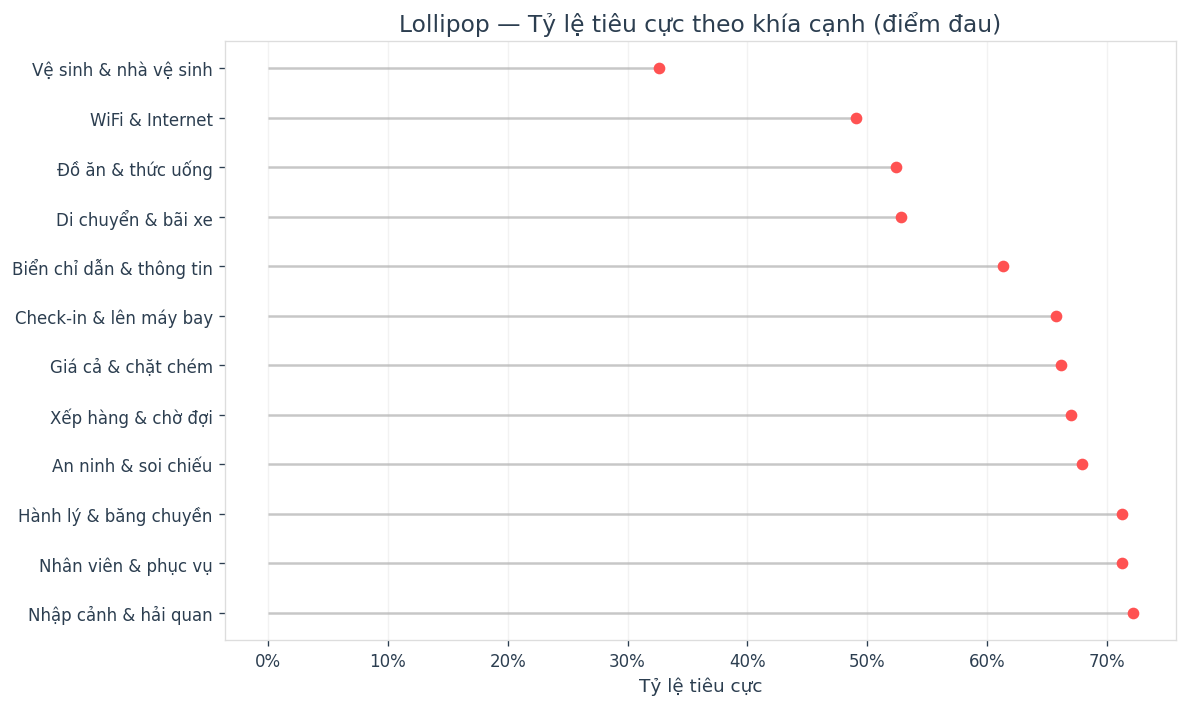

In [63]:
neg_sorted = aspect_summary.sort_values("neg_rate", ascending=False)

plt.figure(figsize=(10, 6))
y = np.arange(len(neg_sorted))
plt.hlines(y=y, xmin=0, xmax=neg_sorted["neg_rate"].values, color="#B0B0B0", alpha=0.7)
plt.plot(neg_sorted["neg_rate"].values, y, "o", color=PALETTE["negative"])

plt.yticks(y, neg_sorted["aspect_vi"])
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.xlabel("Tỷ lệ tiêu cực")
plt.title("Lollipop — Tỷ lệ tiêu cực theo khía cạnh (điểm đau)")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


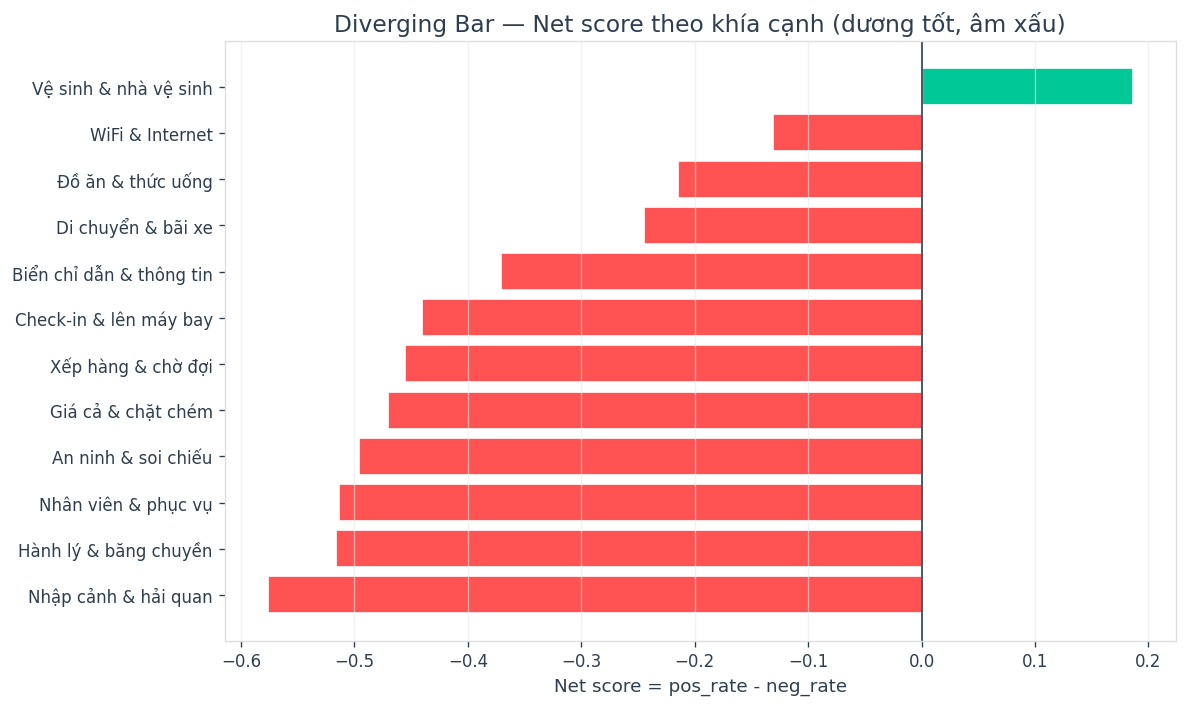

In [64]:
ns = aspect_summary.sort_values("net_score")

plt.figure(figsize=(10, 6))
colors = [PALETTE["positive"] if v > 0 else PALETTE["negative"] for v in ns["net_score"]]
plt.barh(ns["aspect_vi"], ns["net_score"], color=colors, edgecolor="white")

plt.axvline(0, color=PALETTE["accent"], linewidth=1)
plt.title("Diverging Bar — Net score theo khía cạnh (dương tốt, âm xấu)")
plt.xlabel("Net score = pos_rate - neg_rate")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


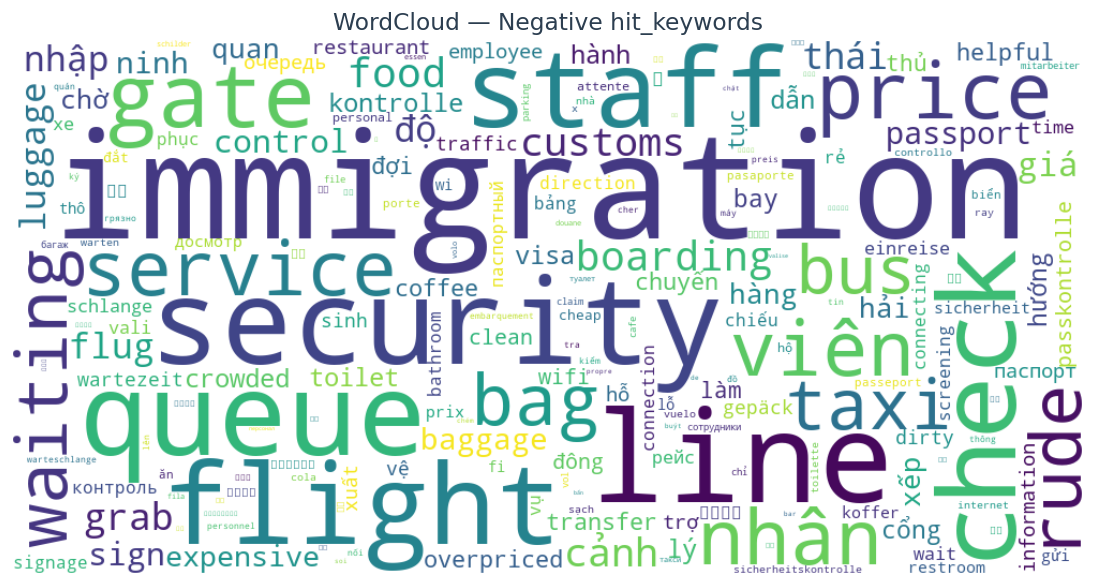

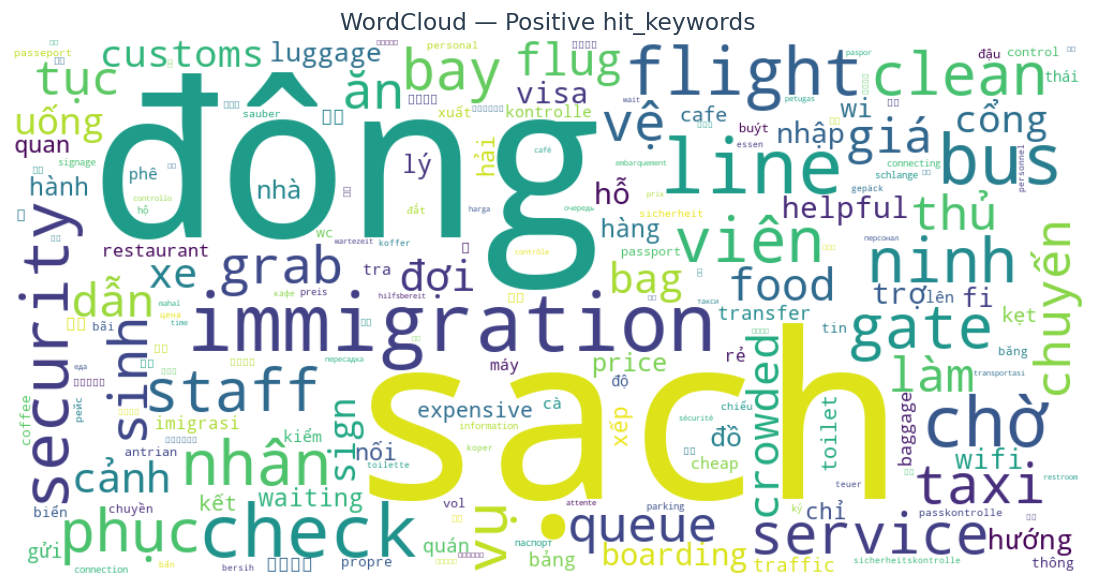

In [65]:
from wordcloud import WordCloud

def keywords_to_text(sub_df: pd.DataFrame) -> str:
    # gom hit_keywords thành 1 chuỗi lớn
    s = sub_df["hit_keywords"].astype("string").fillna("").str.lower()
    s = s.str.replace(",", " ", regex=False)
    return " ".join(s.tolist())

neg_text = keywords_to_text(df[df["label"] == "negative"])
pos_text = keywords_to_text(df[df["label"] == "positive"])

def plot_wordcloud(text, title):
    wc = WordCloud(width=1000, height=500, background_color="white", collocations=False).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_wordcloud(neg_text, "WordCloud — Negative hit_keywords")
plot_wordcloud(pos_text, "WordCloud — Positive hit_keywords")


In [66]:
bubble = aspect_summary.copy()
fig = px.scatter(
    bubble,
    x="n_total",
    y="pos_rate",
    size="n_total",
    color="net_score",
    color_continuous_scale=["#FF5252", "#F1C40F", "#00C897"],
    hover_name="aspect_vi",
    hover_data={"negative": True, "neutral": True, "positive": True, "pos_rate":":.2f", "neg_rate":":.2f"},
    title="Bubble — Điểm sáng vs Thảm hoạ (X: mức nhắc, Y: positive rate, màu: net_score)"
)
fig.update_layout(
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"])
)
fig.update_yaxes(tickformat=".0%")
fig.show()


In [67]:
# chọn top languages để heatmap không rối
top_langs = df["lang"].value_counts().head(10).index.tolist()

lang_aspect = df[df["lang"].isin(top_langs)].copy()
ct_la = pd.crosstab([lang_aspect["lang"], lang_aspect["aspect_vi"]], lang_aspect["label"]).reindex(columns=LABEL_ORDER).fillna(0)
ct_la = ct_la.reset_index()

ct_la["total"] = ct_la[LABEL_ORDER].sum(axis=1)
ct_la["neg_rate"] = (ct_la["negative"] / ct_la["total"]).replace([np.inf, np.nan], 0)

heat = ct_la.pivot(index="lang", columns="aspect_vi", values="neg_rate").fillna(0)

fig = px.imshow(
    heat,
    aspect="auto",
    color_continuous_scale="Reds",
    title="Heatmap — Tỷ lệ tiêu cực theo Ngôn ngữ × Khía cạnh (Top 10 languages)"
)
fig.update_layout(
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"]),
    margin=dict(l=10, r=10, t=60, b=10)
)
fig.show()


In [68]:
sun = df[df["lang"].isin(top_langs)].groupby(["lang", "aspect_vi"]).size().reset_index(name="count")

fig = px.sunburst(
    sun,
    path=["lang", "aspect_vi"],
    values="count",
    title="Sunburst — Cơ cấu góp ý: Ngôn ngữ → Khía cạnh"
)
fig.update_layout(
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"])
)
fig.show()


In [71]:
# gộp count
flow = df[df["lang"].isin(top_langs)].groupby(["lang","aspect_vi","label"]).size().reset_index(name="count")

langs = flow["lang"].unique().tolist()
aspects = flow["aspect_vi"].unique().tolist()
labels = LABEL_ORDER

nodes = langs + aspects + labels
node_index = {n:i for i,n in enumerate(nodes)}

sources = []
targets = []
values  = []
colors  = []

# lang -> aspect
la = flow.groupby(["lang","aspect_vi"])["count"].sum().reset_index()
for _, r in la.iterrows():
    sources.append(node_index[r["lang"]])
    targets.append(node_index[r["aspect_vi"]])
    values.append(int(r["count"]))
    colors.append("rgba(44,62,80,0.35)")  # accent nhẹ

# aspect -> label
al = flow.groupby(["aspect_vi","label"])["count"].sum().reset_index()
for _, r in al.iterrows():
    sources.append(node_index[r["aspect_vi"]])
    targets.append(node_index[r["label"]])
    values.append(int(r["count"]))
    lab = r["label"]
    # map sang màu sentiment
    if lab in PALETTE:
        colors.append(PALETTE[lab])
    else:
        colors.append("rgba(189,189,189,0.8)")

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=14,
        thickness=14,
        line=dict(color="white", width=0.5),
        label=nodes,
        color="rgba(44,62,80,0.12)"
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors
    )
)])
fig.update_layout(
    title="Sankey — Luồng góp ý: Language → Aspect → Sentiment",
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"]),
    margin=dict(l=10, r=10, t=60, b=10)
)
fig.show()


In [72]:
fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=nss,
    number={"suffix": " pts", "valueformat": ".1f"},
    title={"text": "NSS Gauge (Pos% - Neg%)"},
    gauge={
        "axis": {"range": [-100, 100]},
        "bar": {"color": PALETTE["accent"]},
        "steps": [
            {"range": [-100, -20], "color": "#FFCDD2"},
            {"range": [-20, 20], "color": "#FFF9C4"},
            {"range": [20, 100], "color": "#C8E6C9"},
        ],
        "threshold": {"line": {"color": PALETTE["negative"], "width": 3}, "thickness": 0.75, "value": 0}
    }
))
fig.update_layout(
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"]),
    margin=dict(l=20, r=20, t=60, b=20)
)
fig.show()


In [74]:
fig = px.box(
    df,
    x="label",
    y="sent_len_words",
    color="label",
    color_discrete_map={k: PALETTE[k] for k in LABEL_ORDER},
    category_orders={"label": LABEL_ORDER},
    title="Box Plot — Độ dài câu (words) theo cảm xúc"
)
fig.update_layout(
    paper_bgcolor=PALETTE["bg"],
    font=dict(color=PALETTE["accent"])
)
fig.show()


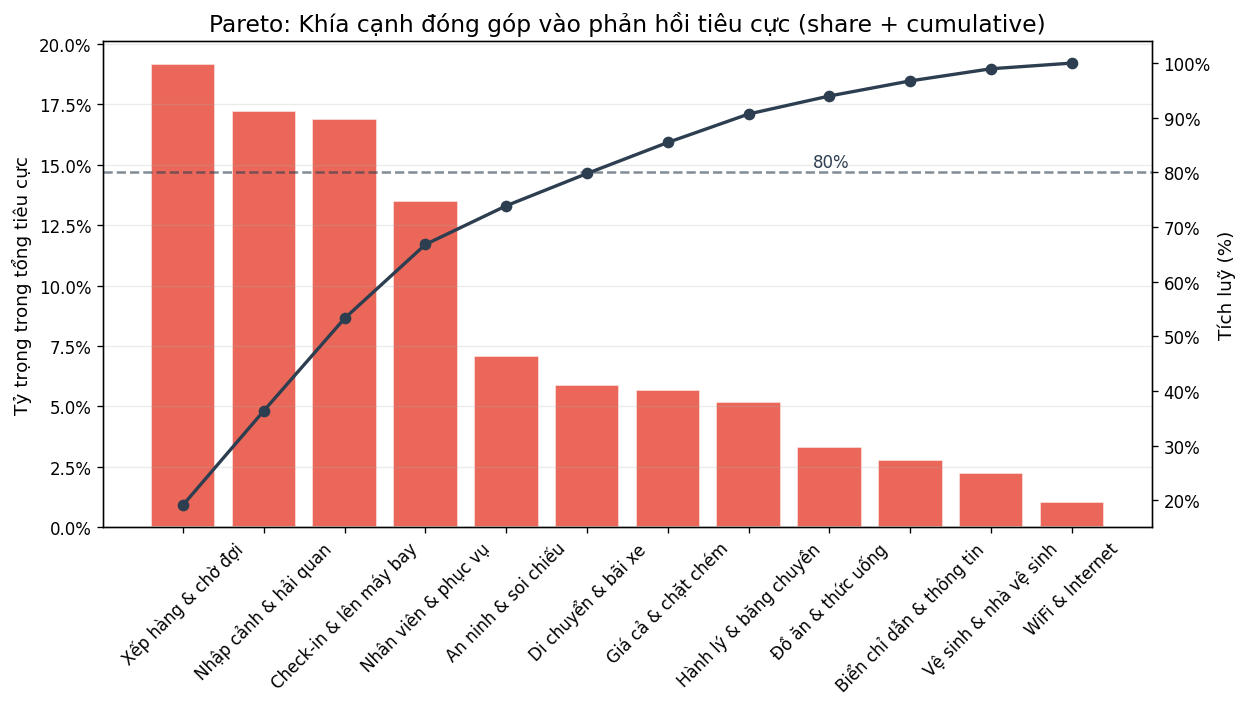

In [48]:
neg_counts = ct2["negative"].sort_values(ascending=False)
neg_share = neg_counts / neg_counts.sum()
cum = neg_share.cumsum()

fig, ax1 = plt.subplots(figsize=(10.5, 6))

bars = ax1.bar(neg_share.index, neg_share.values, color=SENT_COLORS["negative"], alpha=0.85, edgecolor="white")
ax1.set_ylabel("Tỷ trọng trong tổng tiêu cực")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_title("Pareto: Khía cạnh đóng góp vào phản hồi tiêu cực (share + cumulative)")
ax1.grid(axis="y", alpha=0.25)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(neg_share.index, cum.values, marker="o", color="#2C3E50", linewidth=2)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylabel("Tích luỹ (%)")

# đường 80%
ax2.axhline(0.8, color="#2C3E50", linestyle="--", alpha=0.6)
ax2.text(len(cum)*0.65, 0.81, "80%", color="#2C3E50")

plt.tight_layout()
plt.show()
# savefig("06_pareto_negative_contribution.png")


In [52]:
absa_df.to_csv("C:\\Users\\ADMIN\\Desktop\\tsn_review_analytics\\TSN_Data\\processed_data\\processed.csv", index=False, encoding="utf-8-sig")
